# 🐻‍❄️ Polars — Fast DataFrames with a Built-In Query Optimizer

> **What you'll learn:** how Polars stores data in columns, how to write *expressions* instead of loops, group-bys, joins (including **as-of joins** for point-in-time features), **window functions** with `over`, strings/dates/lists/structs, null vs NaN, and the **lazy API** that reads only the data a query needs — all on **3 million real NYC taxi trips**, with honest, measured comparisons against pandas.

| | |
|---|---|
| **Difficulty** | 🟢 Beginner → 🔴 Interview-level |
| **Time** | ~4 hours to read and run, +2 hours for exercises and the project |
| **Prerequisites** | [Pandas](../01_Core_Scientific_Computing/02_Pandas.ipynb) (DataFrames, `groupby`, `merge`) · [SQL with DuckDB](../01_Core_Scientific_Computing/03_SQL_with_DuckDB.ipynb) (joins, window functions) |
| **Tested with** | Python 3.12 · polars 1.44 · pandas 3.0 · pyarrow 25 · duckdb 1.5 |
| **Interview relevance** | ⭐⭐ Medium-High — "pandas vs Polars vs Spark?", lazy evaluation and predicate/projection pushdown, top-N per group with window functions, point-in-time joins, "your data doesn't fit in RAM — now what?" |

## 🤔 What Is Polars?

**Polars** is a DataFrame library (tables of rows and columns, like pandas) written in Rust, with a Python API.

Imagine two ways to cook a big dinner:

- **pandas** is a single cook who follows your instructions **one line at a time**. "Chop all the vegetables." Done. "Now throw away the carrots." Done — but the carrots were already chopped, which wasted time.
- **Polars (lazy mode)** is a head chef who first reads your **whole recipe**, notices you never use the carrots, skips chopping them, and then splits the work across **several cooks** at once.

Three ideas make that possible:

| Idea | Plain-English meaning |
|---|---|
| **Columnar memory (Apache Arrow)** | Each column is one tightly packed block of values of one type, so the CPU can scan it quickly. Arrow is a standard format many tools share. |
| **Multithreading** | Polars splits work across all your CPU cores automatically. |
| **Lazy query optimizer** | You describe *what* you want; Polars builds a **query plan** (a recipe) and rewrites it to do less work before running it. |

```
Eager (pandas style):  read ALL 19 columns → filter → compute → aggregate
Lazy  (Polars):        plan → optimize → read only 4 columns, filter WHILE reading → aggregate
```

## 🎯 Why It Matters

- **Bigger data on one machine.** Many "big data" jobs are really 5–100 GB. Polars (and DuckDB) handle that on a laptop or a single cloud VM, which is much cheaper and simpler than a Spark cluster.
- **Faster feature engineering.** ML pipelines spend most of their time cleaning, joining, and aggregating. Multi-core group-bys, joins, and window functions make iteration loops shorter.
- **Production pipelines.** Polars' expression API is explicit and has no index, which makes pipelines easier to read, test, and keep free of silent alignment bugs.
- **In interviews** you will hear: *"What is lazy evaluation?"*, *"Explain predicate pushdown"*, *"How would you process a file bigger than RAM?"*, *"When would you pick pandas, Polars, DuckDB, or Spark?"*, *"Get the top 3 items per group"*, and *"How do you join features without leaking the future?"* This notebook practises all of them.

## ✅ By the End You Can

- [ ] Load real CSV and Parquet data and explain why Polars is fast (columns, threads, optimizer) — with measurements
- [ ] Write expressions in `select`, `with_columns`, `filter`, and `group_by().agg()`, including `when/then/otherwise`
- [ ] Join tables safely, including **as-of joins** for point-in-time features, and compute **window functions** with `over`
- [ ] Handle strings, datetimes, lists, structs, and the difference between **null and NaN**
- [ ] Read a lazy **query plan** with `explain()`, spot predicate/projection pushdown, and run queries in **streaming** mode
- [ ] Build a tiny lazy query engine with pushdown from scratch, and run a fair performance comparison with pandas

## 📋 Table of Contents

1. [Loading Real Data: Parquet and CSV](#1.-Loading-Real-Data:-Parquet-and-CSV-🟢)
2. [Why Polars Is Fast: Columns, Threads, and an Optimizer](#2.-Why-Polars-Is-Fast:-Columns,-Threads,-and-an-Optimizer-🟢)
3. [Expressions and Contexts](#3.-Expressions-and-Contexts-🟢)
4. [Group By and Aggregations](#4.-Group-By-and-Aggregations-🟢)
5. [Conditional Logic: when / then / otherwise](#5.-Conditional-Logic:-when-/-then-/-otherwise-🟢)
6. [Joins](#6.-Joins-🟡)
7. [As-of Joins for Point-in-Time Features](#7.-As-of-Joins-for-Point-in-Time-Features-🔴)
8. [Window Functions with over](#8.-Window-Functions-with-over-🟡)
9. [Strings, Datetimes, Lists, and Structs](#9.-Strings,-Datetimes,-Lists,-and-Structs-🟡)
10. [Missing Data: null vs NaN](#10.-Missing-Data:-null-vs-NaN-🟡)
11. [The Lazy API: Query Plans and Pushdown](#11.-The-Lazy-API:-Query-Plans-and-Pushdown-🟡)
12. [Streaming and Out-of-Core Execution](#12.-Streaming-and-Out-of-Core-Execution-🔴)
13. [Interop: pandas, NumPy, Arrow, and DuckDB](#13.-Interop:-pandas,-NumPy,-Arrow,-and-DuckDB-🟢)
14. [A Fair Performance Comparison with pandas](#14.-A-Fair-Performance-Comparison-with-pandas-🟡)
- [🔧 Build It From Scratch](#🔧-Build-It-From-Scratch) · [⚠️ Common Pitfalls](#⚠️-Common-Pitfalls) · [🏋️ Practice Exercises](#🏋️-Practice-Exercises) · [🚀 Mini Project](#🚀-Mini-Project:-A-Lazy-Analytics-Pipeline-on-NYC-Taxi-Trips) · [🎤 Interview Q&A](#🎤-Interview-Q&A) · [🧪 Quick Quiz](#🧪-Quick-Quiz) · [📚 Resources](#📚-Resources) · [📝 Summary](#📝-Summary-Cheat-Sheet)

## ⚙️ Setup

Run the cell below first. If a package is missing, uncomment the `%pip` line, run it once, then restart the kernel.

- `DATA_DIR` is where the real taxi data is cached (`_outputs/`, ignored by git). The Dask notebook reuses the same cache.
- `run_in_fresh_process(fn, ...)` runs a function in a **brand-new Python process** and reports its wall time and **peak memory** (RSS, the RAM the process actually holds). A fresh process is the only fair way to compare memory: inside this notebook, memory from earlier cells would pollute the numbers.
- `check()` gives instant feedback on exercises: **✅** correct, **⏳** not attempted yet, **❌** wrong (with a hint). It accepts a Polars DataFrame, a list of row tuples, a tuple (one row), or a single value.

In [1]:
# %pip install -q "polars>=1.30" "pandas>=3.0" "pyarrow>=20" "duckdb>=1.3" psutil cloudpickle matplotlib

import datetime as dt
import math
import os
import pickle
import re
import subprocess
import sys
import threading
import time
import urllib.request
import warnings
from pathlib import Path

import cloudpickle
import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import polars.selectors as cs
import psutil
import pyarrow as pa
import pyarrow.parquet as pq
from polars.testing import assert_frame_equal

print(f"Python {sys.version.split()[0]} | polars {pl.__version__} | pandas {pd.__version__} | "
      f"pyarrow {pa.__version__} | duckdb {duckdb.__version__}")
print(f"CPU cores: {os.cpu_count()} | Polars thread pool: {pl.thread_pool_size()} threads | "
      f"RAM: {psutil.virtual_memory().total / 2**30:.0f} GiB")

OUTPUT_DIR = Path("_outputs")                         # files we write go here (ignored by git)
DATA_DIR = OUTPUT_DIR / "nyc_taxi"
DATA_DIR.mkdir(parents=True, exist_ok=True)

pl.Config.set_tbl_rows(8)                             # print at most 8 rows of a table
pl.Config.set_tbl_cols(10)
pl.Config.set_fmt_str_lengths(40)

_CHILD = ("import cloudpickle, pickle, sys; fn, args = cloudpickle.load(sys.stdin.buffer); "
          "sys.stdout.buffer.write(pickle.dumps(fn(*args)))")


def run_in_fresh_process(fn, *args, env=None, interval=0.01):
    """Run fn(*args) in a new Python process. Returns (result, wall_seconds, peak_rss_MB)."""
    start = time.perf_counter()
    proc = subprocess.Popen([sys.executable, "-c", _CHILD], stdin=subprocess.PIPE, stdout=subprocess.PIPE,
                            stderr=subprocess.PIPE, env={**os.environ, **(env or {})})
    peak = 0

    def sample():                                     # poll RSS of the process and any children it starts
        nonlocal peak
        parent = psutil.Process(proc.pid)
        while proc.poll() is None:
            try:
                rss = parent.memory_info().rss + sum(c.memory_info().rss for c in parent.children(recursive=True))
                peak = max(peak, rss)
            except psutil.Error:
                pass
            time.sleep(interval)

    sampler = threading.Thread(target=sample)
    sampler.start()
    out, err = proc.communicate(cloudpickle.dumps((fn, args)))
    sampler.join()
    if proc.returncode != 0:
        raise RuntimeError(err.decode()[-1500:])
    return pickle.loads(out), time.perf_counter() - start, peak / 1e6


def _rows(value):
    """Normalize a DataFrame, list of rows, tuple (one row), or scalar into a list of tuples."""
    if isinstance(value, pl.DataFrame):
        return value.rows()
    if isinstance(value, pl.Series):
        return [(v,) for v in value.to_list()]
    if isinstance(value, list):
        return [tuple(v) if isinstance(v, (list, tuple)) else (v,) for v in value]
    if isinstance(value, tuple):
        return [value]
    return [(value,)]


def _same(a, b):
    if isinstance(a, (int, float, np.integer, np.floating)) and isinstance(b, (int, float, np.integer, np.floating)):
        return math.isclose(float(a), float(b), rel_tol=1e-6, abs_tol=1e-9)
    return a == b


def check(name, got, expected, hint=""):
    """✅ if correct, ⏳ if not attempted yet (None), ❌ AssertionError with a hint otherwise."""
    if got is None or got is ...:
        print(f"⏳ {name}: not attempted yet — replace None with your answer.")
        return
    got_rows, exp_rows = _rows(got), _rows(expected)
    if len(got_rows) != len(exp_rows):
        raise AssertionError(f"❌ {name}: got {len(got_rows)} row(s), expected {len(exp_rows)}. {hint}")
    for g, e in zip(got_rows, exp_rows):
        if len(g) != len(e) or not all(_same(x, y) for x, y in zip(g, e)):
            raise AssertionError(f"❌ {name}: row {g} is not quite right (check columns, order, rounding). {hint}")
    print(f"✅ {name}: correct!")

Python 3.12.11 | polars 1.44.2 | pandas 3.0.5 | pyarrow 25.0.1 | duckdb 1.5.5
CPU cores: 15 | Polars thread pool: 15 threads | RAM: 24 GiB


## 1. Loading Real Data: Parquet and CSV 🟢

We use the official **NYC Taxi & Limousine Commission (TLC) trip records**: every yellow-cab trip in **January 2024** (about 3 million rows), plus the **taxi zone lookup** table that turns zone IDs into neighbourhood names.

- **CSV** is plain text: easy to open, but every read must parse text into numbers and guess types.
- **Parquet** is a binary, **columnar** file format: values are stored column by column, typed and compressed, with metadata that lets a reader skip columns (and sometimes rows) it doesn't need.

The download (~50 MB) happens once and is cached in `_outputs/nyc_taxi/`. We verify the row count stored in the Parquet metadata, so you know you have exactly the data this notebook was written against.

In [2]:
TLC = "https://d37ci6vzurychx.cloudfront.net"
DATASETS = {  # file name → (URL, expected rows; None for the small CSV)
    "yellow_tripdata_2024-01.parquet": (f"{TLC}/trip-data/yellow_tripdata_2024-01.parquet", 2_964_624),
    "taxi_zone_lookup.csv": (f"{TLC}/misc/taxi_zone_lookup.csv", None),
}


def download(name):
    url, expected_rows = DATASETS[name]
    path = DATA_DIR / name
    if not path.exists():
        request = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0 (course notebook)"})
        with urllib.request.urlopen(request, timeout=120) as resp:
            path.write_bytes(resp.read())
        print(f"downloaded {name} ({path.stat().st_size / 1e6:.1f} MB)")
    if expected_rows is not None:
        rows = pq.ParquetFile(path).metadata.num_rows
        if rows != expected_rows:
            raise RuntimeError(f"{name} has {rows:,} rows, expected {expected_rows:,}. TLC may have revised the file: "
                               f"delete {path} and re-run, and expect exercise answers to differ slightly.")
    return path


TRIPS_PATH = download("yellow_tripdata_2024-01.parquet")
ZONES_PATH = download("taxi_zone_lookup.csv")
print(f"✅ {TRIPS_PATH.name}: {TRIPS_PATH.stat().st_size / 1e6:.1f} MB on disk | {ZONES_PATH.name}: {ZONES_PATH.stat().st_size / 1e3:.1f} KB")

✅ yellow_tripdata_2024-01.parquet: 50.0 MB on disk | taxi_zone_lookup.csv: 12.3 KB


In [3]:
raw = pl.read_parquet(TRIPS_PATH)                      # eager: load the whole file into memory now
print(f"shape: {raw.shape} | in memory: {raw.estimated_size('mb'):.0f} MB")
print(raw.schema)
raw.head(3)

shape: (2964624, 19) | in memory: 376 MB
Schema({'VendorID': Int32, 'tpep_pickup_datetime': Datetime(time_unit='ns', time_zone=None), 'tpep_dropoff_datetime': Datetime(time_unit='ns', time_zone=None), 'passenger_count': Int64, 'trip_distance': Float64, 'RatecodeID': Int64, 'store_and_fwd_flag': String, 'PULocationID': Int32, 'DOLocationID': Int32, 'payment_type': Int64, 'fare_amount': Float64, 'extra': Float64, 'mta_tax': Float64, 'tip_amount': Float64, 'tolls_amount': Float64, 'improvement_surcharge': Float64, 'total_amount': Float64, 'congestion_surcharge': Float64, 'Airport_fee': Float64})


VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,…,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
i32,datetime[ns],datetime[ns],i64,f64,…,f64,f64,f64,f64,f64
2,2024-01-01 00:57:55,2024-01-01 01:17:43,1,1.72,…,0.0,1.0,22.7,2.5,0.0
1,2024-01-01 00:03:00,2024-01-01 00:09:36,1,1.8,…,0.0,1.0,18.75,2.5,0.0
1,2024-01-01 00:17:06,2024-01-01 00:35:01,1,4.7,…,0.0,1.0,31.3,2.5,0.0


Every column has **one type** (`Int32`, `Float64`, `Datetime[ns]`, `String`…). The schema came from the Parquet file itself — nothing was guessed.

Now the CSV. We tell Polars the type of `LocationID` with `schema_overrides`, so it matches the `Int32` zone columns in the trips table (join keys should have the same type).

In [4]:
zones = pl.read_csv(ZONES_PATH, schema_overrides={"LocationID": pl.Int32})
print(zones.shape, zones.schema)
zones.head(4)

(265, 4) Schema({'LocationID': Int32, 'Borough': String, 'Zone': String, 'service_zone': String})


LocationID,Borough,Zone,service_zone
i32,str,str,str
1,"""EWR""","""Newark Airport""","""EWR"""
2,"""Queens""","""Jamaica Bay""","""Boro Zone"""
3,"""Bronx""","""Allerton/Pelham Gardens""","""Boro Zone"""
4,"""Manhattan""","""Alphabet City""","""Yellow Zone"""


In [5]:
# You can also build DataFrames by hand — a dict of columns, or rows plus a schema
small = pl.DataFrame({"zone": ["JFK Airport", "Midtown Center"], "trips": [145_240, 143_471]})
from_rows = pl.DataFrame([("a", 1), ("b", 2)], schema={"letter": pl.String, "n": pl.Int64}, orient="row")
print(small, from_rows, sep="\n")

shape: (2, 2)
┌────────────────┬────────┐
│ zone           ┆ trips  │
│ ---            ┆ ---    │
│ str            ┆ i64    │
╞════════════════╪════════╡
│ JFK Airport    ┆ 145240 │
│ Midtown Center ┆ 143471 │
└────────────────┴────────┘
shape: (2, 2)
┌────────┬─────┐
│ letter ┆ n   │
│ ---    ┆ --- │
│ str    ┆ i64 │
╞════════╪═════╡
│ a      ┆ 1   │
│ b      ┆ 2   │
└────────┴─────┘


### ✍️ Your Turn

How many taxi zones in `zones` belong to the **Manhattan** borough? Store an integer in `n_manhattan_zones`.

In [6]:
n_manhattan_zones = None  # TODO: your code here
check("n_manhattan_zones", n_manhattan_zones, 69, hint="zones.filter(pl.col('Borough') == 'Manhattan').height")

⏳ n_manhattan_zones: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
n_manhattan_zones = zones.filter(pl.col("Borough") == "Manhattan").height
check("n_manhattan_zones", n_manhattan_zones, 69)
```

`.height` is the number of rows (`.width` is the number of columns). `len(df)` works too.
</details>

> 💡 **Interview angle:** "Why store analytics data as Parquet instead of CSV?" — typed columns (no parsing or type guessing), compression, and column/row-group metadata that lets engines read only the columns and row groups a query needs.

## 2. Why Polars Is Fast: Columns, Threads, and an Optimizer 🟢

```
Row-oriented (a list of records)        Columnar (Apache Arrow)
┌──────────┬───────┬──────┐              fare_amount: [ 17.7 | 10.0 | 23.3 | ... ]  ← one typed block
│ 17.7     │ 1.72  │ 2.70 │              trip_dist  : [ 1.72 | 1.80 | 4.70 | ... ]
│ 10.0     │ 1.80  │ 3.00 │              tip_amount : [ 2.70 | 3.00 | 0.00 | ... ]
└──────────┴───────┴──────┘
averaging fares touches every row          averaging fares scans ONE contiguous block
```

Let's **measure** the multithreading claim instead of trusting it. We run the same group-by + window query twice in fresh processes: once with Polars limited to **1 thread** (`POLARS_MAX_THREADS=1`), once with the default thread pool. Timing happens *inside* the child process, so Python start-up time is excluded.

In [7]:
def route_query(path):
    """Group-by on (pickup, dropoff) plus a per-zone window rank — typical feature-engineering work."""
    import time
    import polars as pl
    df = pl.read_parquet(path, columns=["PULocationID", "DOLocationID", "fare_amount", "trip_distance"])
    start = time.perf_counter()
    routes = (
        df.group_by("PULocationID", "DOLocationID")
        .agg(trips=pl.len(), median_fare=pl.col("fare_amount").median(), mean_dist=pl.col("trip_distance").mean())
        .with_columns(rank_in_zone=pl.col("trips").rank("ordinal", descending=True).over("PULocationID"))
        .sort("PULocationID", "DOLocationID")
    )
    return routes, time.perf_counter() - start, pl.thread_pool_size()


(one_thread, t_one, n1), _, _ = run_in_fresh_process(route_query, str(TRIPS_PATH.resolve()), env={"POLARS_MAX_THREADS": "1"})
(many_threads, t_many, n_many), _, _ = run_in_fresh_process(route_query, str(TRIPS_PATH.resolve()))
assert_frame_equal(one_thread.drop("rank_in_zone"), many_threads.drop("rank_in_zone"))   # same answers (ranks can differ only on ties)
print(f"{n1} thread : {t_one * 1000:6.0f} ms")
print(f"{n_many} threads: {t_many * 1000:6.0f} ms  → {t_one / t_many:.1f}× faster with the same result")

1 thread :     92 ms
15 threads:     22 ms  → 4.3× faster with the same result


The speed-up is real but smaller than the number of threads: some steps (like the final sort's merge, or memory allocation) don't split perfectly, and small groups don't give each thread much work. That's normal — it's **Amdahl's law** (the part that can't be parallelized limits the total speed-up).

**So is Polars always the right tool? No.**

| Situation | Usually the better choice | Why |
|---|---|---|
| Small data, notebooks, libraries that expect pandas (statsmodels, many plotting tools) | **pandas** | Huge ecosystem, everyone knows it; speed doesn't matter for 10k rows |
| Your team thinks in SQL, or you query many Parquet files ad hoc | **DuckDB** | Same columnar/vectorized ideas behind a SQL interface |
| Data too big for one machine (hundreds of GB – TB), or you already run a cluster | **Spark** (or Dask) | Distributes work over many machines, fault-tolerant |
| Single machine, 1 GB – ~100 GB, Python pipelines | **Polars** | Multi-core, lazy optimizer, streaming for larger-than-RAM data |

> 💡 **Interview angle:** "Why is Polars faster than pandas?" — Arrow columnar memory, a Rust engine that uses all cores, and a lazy optimizer (pushdown, expression simplification). Add the honest caveat: pandas' core operations are vectorized C code too, so the gap depends on the operation — measure it (section 14).

## 3. Expressions and Contexts 🟢

The most important Polars idea: an **expression** is a *recipe for a column* — for example "take `tip_amount`, divide by `fare_amount`". It does nothing until you use it inside a **context**:

| Context | What it does | Output rows |
|---|---|---|
| `df.select(exprs)` | compute these columns (and only these) | same, or 1 if you aggregate |
| `df.with_columns(exprs)` | add or replace columns, keep the rest | same |
| `df.filter(expr)` | keep rows where the boolean expression is true | fewer |
| `df.group_by(keys).agg(exprs)` | compute expressions per group | one per group |

Expressions inside one context run **in parallel**, so you can't use a column created in that same context (see Pitfalls).

In [8]:
duration_min = (pl.col("tpep_dropoff_datetime") - pl.col("tpep_pickup_datetime")).dt.total_seconds() / 60
print("an expression is just a recipe:", duration_min)

raw.select(
    pl.col("tpep_pickup_datetime"),
    pl.col("fare_amount"),
    duration_min.alias("duration_min"),
    (pl.col("tip_amount") / pl.col("fare_amount")).round(3).alias("tip_ratio"),
).head(4)

an expression is just a recipe: [([(col("tpep_dropoff_datetime")) - (col("tpep_pickup_datetime"))].dt.total_seconds()) / (dyn int: 60)]


tpep_pickup_datetime,fare_amount,duration_min,tip_ratio
datetime[ns],f64,f64,f64
2024-01-01 00:57:55,17.7,19.8,0.0
2024-01-01 00:03:00,10.0,6.6,0.375
2024-01-01 00:17:06,23.3,17.916667,0.129
2024-01-01 00:36:38,10.0,8.3,0.2


In [9]:
trips = raw.with_columns(                              # keeps all 19 columns and adds 3 more
    duration_min=duration_min,                         # keyword arguments name the new columns
    pickup_hour=pl.col("tpep_pickup_datetime").dt.hour(),
    is_card=pl.col("payment_type") == 1,
)
print(f"columns before: {raw.width} | after with_columns: {trips.width}")

# Selectors pick columns by type or name pattern
print("float columns:", trips.select(cs.float()).columns[:5], "…")
trips.select(cs.by_name("fare_amount", "tip_amount"), cs.ends_with("_min")).head(3)

columns before: 19 | after with_columns: 22
float columns: ['trip_distance', 'fare_amount', 'extra', 'mta_tax', 'tip_amount'] …


fare_amount,tip_amount,duration_min
f64,f64,f64
17.7,0.0,19.8
10.0,3.75,6.6
23.3,3.0,17.916667


In [10]:
# filter: combine conditions with & (and), | (or), ~ (not) — each condition in parentheses or as a method
airport_rush = trips.filter(
    pl.col("PULocationID").is_in([132, 138])           # JFK or LaGuardia
    & pl.col("pickup_hour").is_between(16, 19)          # 4 pm – 7:59 pm (both ends included)
    & (pl.col("fare_amount") > 0)
)
print(f"airport pickups in the evening rush: {airport_rush.height:,} of {trips.height:,} trips")

airport pickups in the evening rush: 62,667 of 2,964,624 trips


### ✍️ Your Turn

How many trips in `raw` have a `trip_distance` **greater than 20 miles**? Store an integer in `n_long_trips`.

In [11]:
n_long_trips = None  # TODO: your code here
check("n_long_trips", n_long_trips, 29_519, hint="raw.filter(pl.col('trip_distance') > 20).height")

⏳ n_long_trips: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
n_long_trips = raw.filter(pl.col("trip_distance") > 20).height
check("n_long_trips", n_long_trips, 29_519)
```

An aggregation expression works too: `raw.select((pl.col("trip_distance") > 20).sum()).item()` — `True` counts as 1.
</details>

> 💡 **Interview angle:** "What is an expression in Polars?" — a lazy, composable description of a column computation (`pl.col("a") / pl.col("b")`) that the engine can optimize and run in parallel; contexts (`select`, `with_columns`, `filter`, `agg`) decide how its result is used.

## 4. Group By and Aggregations 🟢

`group_by(keys).agg(...)` splits rows into groups and runs **any expressions** per group — including filters and conditions inside the aggregation, which pandas needs extra steps for.

In [12]:
per_zone = (
    trips.group_by("PULocationID")
    .agg(
        trips=pl.len(),                                               # rows per group
        avg_fare=pl.col("fare_amount").mean().round(2),
        median_tip=pl.col("tip_amount").median(),
        card_share=pl.col("is_card").mean().round(3),                 # mean of booleans = share of True
        avg_card_tip=pl.col("tip_amount").filter(pl.col("is_card")).mean().round(2),   # conditional aggregation
    )
    .sort("trips", descending=True)
)
per_zone.head(5)

PULocationID,trips,avg_fare,median_tip,card_share,avg_card_tip
i32,u32,f64,f64,f64,f64
132,145240,59.4,9.94,0.712,12.39
161,143471,15.21,2.88,0.802,3.79
237,142708,12.18,2.5,0.815,3.12
236,136465,12.71,2.5,0.817,3.15
162,106717,14.79,2.83,0.815,3.66


busiest pickup hour: 18:00 with 212,788 trips | quietest: 4:00 with 16,742


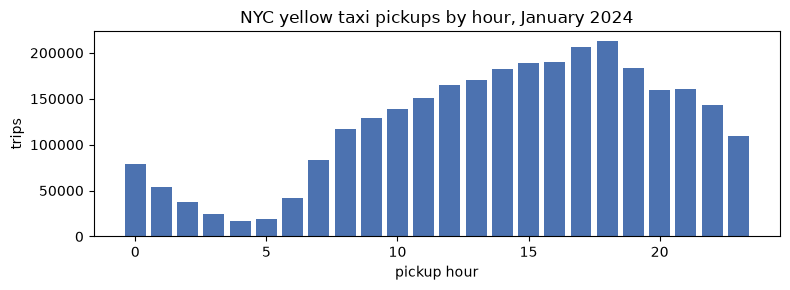

In [13]:
# group_by output order is NOT guaranteed (groups are built in parallel): sort, or ask for maintain_order=True
by_hour = trips.group_by("pickup_hour", maintain_order=False).agg(trips=pl.len()).sort("pickup_hour")
busiest_hour = by_hour.sort("trips", descending=True).row(0)
print(f"busiest pickup hour: {busiest_hour[0]}:00 with {busiest_hour[1]:,} trips | quietest: "
      f"{by_hour.sort('trips').row(0)[0]}:00 with {by_hour['trips'].min():,}")

fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(by_hour["pickup_hour"], by_hour["trips"], color="#4C72B0")
ax.set(xlabel="pickup hour", ylabel="trips", title="NYC yellow taxi pickups by hour, January 2024")
plt.tight_layout()
plt.show()

### ✍️ Your Turn

Which pickup zone (`PULocationID`) had the **most trips**, and how many? Store a tuple `(zone_id, trips)` in `busiest_zone`.

In [14]:
busiest_zone = None  # TODO: your code here
check("busiest_zone", busiest_zone, (132, 145_240), hint="group_by + pl.len(), sort descending, then .row(0)")

⏳ busiest_zone: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
busiest_zone = raw.group_by("PULocationID").agg(pl.len()).sort("len", descending=True).row(0)
check("busiest_zone", busiest_zone, (132, 145_240))
```

Zone 132 is **JFK Airport**. `.row(0)` returns the first row as a tuple. `raw["PULocationID"].value_counts(sort=True)` gives the same answer.
</details>

> 💡 **Interview angle:** "Why does my group-by result come back in a different order each run?" — groups are computed in parallel, so order isn't guaranteed; sort explicitly (or `maintain_order=True`, which costs speed). Never rely on implicit order in tests.

## 5. Conditional Logic: when / then / otherwise 🟢

`pl.when(condition).then(value).when(...).then(...).otherwise(fallback)` is Polars' vectorized **if / elif / else** (SQL's `CASE WHEN`). It runs on whole columns at once — never write a Python `if` inside a loop over rows.

In [15]:
PAYMENT_NAMES = {0: "flex fare", 1: "credit card", 2: "cash", 3: "no charge", 4: "dispute", 5: "unknown", 6: "voided"}

labelled = trips.select(
    "trip_distance",
    "payment_type",
    distance_class=pl.when(pl.col("trip_distance") < 2).then(pl.lit("short"))
                     .when(pl.col("trip_distance") < 10).then(pl.lit("medium"))
                     .otherwise(pl.lit("long")),
    payment=pl.col("payment_type").replace_strict(PAYMENT_NAMES, default="other"),   # map codes → labels
    capped_fare=pl.when(pl.col("fare_amount") > 200).then(200.0).otherwise(pl.col("fare_amount")),
)
print(labelled.head(4))
print(labelled["payment"].value_counts(sort=True))

shape: (4, 5)
┌───────────────┬──────────────┬────────────────┬─────────────┬─────────────┐
│ trip_distance ┆ payment_type ┆ distance_class ┆ payment     ┆ capped_fare │
│ ---           ┆ ---          ┆ ---            ┆ ---         ┆ ---         │
│ f64           ┆ i64          ┆ str            ┆ str         ┆ f64         │
╞═══════════════╪══════════════╪════════════════╪═════════════╪═════════════╡
│ 1.72          ┆ 2            ┆ short          ┆ cash        ┆ 17.7        │
│ 1.8           ┆ 1            ┆ short          ┆ credit card ┆ 10.0        │
│ 4.7           ┆ 1            ┆ medium         ┆ credit card ┆ 23.3        │
│ 1.4           ┆ 1            ┆ short          ┆ credit card ┆ 10.0        │
└───────────────┴──────────────┴────────────────┴─────────────┴─────────────┘
shape: (5, 2)
┌─────────────┬─────────┐
│ payment     ┆ count   │
│ ---         ┆ ---     │
│ str         ┆ u32     │
╞═════════════╪═════════╡
│ credit card ┆ 2319046 │
│ cash        ┆ 439191  │
│ flex far

The payment codes come from the official [Data Dictionary – Yellow Taxi Trip Records](https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf) (code 0 = "Flex Fare trip"). `replace_strict` raises an error for a code missing from the mapping unless you give a `default` — safer than silently producing nulls.

### ✍️ Your Turn

Using `when/then/otherwise` on `raw`, classify each trip as `"short"` (distance < 2), `"medium"` (< 10) or `"long"` (otherwise) in a column named `distance_class`, then count trips per class. Store a DataFrame with columns `distance_class, len`, **sorted by `distance_class`**, in `class_counts`.

In [16]:
class_counts = None  # TODO: your code here
check("class_counts", class_counts, [("long", 229_457), ("medium", 1_011_027), ("short", 1_724_140)],
      hint="raw.select(distance_class=pl.when(...).then(...)...).group_by('distance_class').len().sort('distance_class')")

⏳ class_counts: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
class_counts = (
    raw.select(
        distance_class=pl.when(pl.col("trip_distance") < 2).then(pl.lit("short"))
        .when(pl.col("trip_distance") < 10).then(pl.lit("medium"))
        .otherwise(pl.lit("long"))
    )
    .group_by("distance_class").len()
    .sort("distance_class")
)
check("class_counts", class_counts, [("long", 229_457), ("medium", 1_011_027), ("short", 1_724_140)])
```

`group_by(...).len()` is a shortcut for `.agg(pl.len())`. Conditions are checked **in order**, so a 1-mile trip matches `< 2` first and never reaches `< 10`.
</details>

> 💡 **Interview angle:** "How do you write if/else logic on a DataFrame efficiently?" — vectorized `when/then/otherwise` (or `np.where` / SQL `CASE`), never `apply` with a Python function per row.

## 6. Joins 🟡

| `how=` | Keeps | Typical use |
|---|---|---|
| `"inner"` | only matching pairs | combine facts that must exist on both sides |
| `"left"` | every left row (nulls when no match) | enrich trips with zone names |
| `"full"` | every row from both sides | reconcile two sources |
| `"semi"` | left rows that **have** a match (no right columns, no duplicates) | "zones that had a pickup" |
| `"anti"` | left rows with **no** match | data-quality checks, "never ordered" |
| `"cross"` | every combination | small grids |

Two safety habits: **join on keys of the same type**, and pass `validate="m:1"` (many-to-one) when you expect the right side's key to be unique — Polars then raises an error instead of silently duplicating rows.

In [17]:
pickup_zones = zones.select(pl.col("LocationID").alias("PULocationID"),
                            pl.col("Borough").alias("pu_borough"), pl.col("Zone").alias("pu_zone"))
dropoff_zones = zones.select(pl.col("LocationID").alias("DOLocationID"),
                             pl.col("Borough").alias("do_borough"), pl.col("Zone").alias("do_zone"))

enriched = (
    trips.join(pickup_zones, on="PULocationID", how="left", validate="m:1")
         .join(dropoff_zones, on="DOLocationID", how="left", validate="m:1")
)
assert enriched.height == trips.height, "a many-to-one left join must not change the row count"
print(f"rows before: {trips.height:,} | after two left joins: {enriched.height:,}")
enriched.select("tpep_pickup_datetime", "pu_borough", "pu_zone", "do_zone", "fare_amount").head(4)

rows before: 2,964,624 | after two left joins: 2,964,624


tpep_pickup_datetime,pu_borough,pu_zone,do_zone,fare_amount
datetime[ns],str,str,str,f64
2024-01-01 00:57:55,"""Manhattan""","""Penn Station/Madison Sq West""","""East Village""",17.7
2024-01-01 00:03:00,"""Manhattan""","""Lenox Hill East""","""Upper East Side North""",10.0
2024-01-01 00:17:06,"""Manhattan""","""Upper East Side North""","""East Village""",23.3
2024-01-01 00:36:38,"""Manhattan""","""East Village""","""SoHo""",10.0


In [18]:
# anti join: trips whose zone ID is missing from the lookup (a data-quality check)
missing_ids = trips.join(zones, left_on="PULocationID", right_on="LocationID", how="anti").height
# the lookup has two placeholder zones: 264 "Unknown" and 265 "Outside of NYC"
placeholder = trips.filter(pl.col("PULocationID").is_in([264, 265]) | pl.col("DOLocationID").is_in([264, 265])).height
# semi join: zones with at least one pickup this month
active_zones = zones.join(trips, left_on="LocationID", right_on="PULocationID", how="semi").height
print(f"pickup IDs missing from lookup: {missing_ids} | trips touching placeholder zones 264/265: {placeholder:,} | "
      f"zones with ≥1 pickup: {active_zones} of {zones.height}")

pickup IDs missing from lookup: 0 | trips touching placeholder zones 264/265: 31,527 | zones with ≥1 pickup: 260 of 265


In [19]:
# Why validate matters: zone NAMES are not unique in the lookup (e.g. "Corona" is IDs 56 and 57)
dup_names = zones.filter(pl.col("Zone").is_duplicated()).select("LocationID", "Zone")
print(dup_names)
by_name = enriched.join(zones.select("Zone", "service_zone"), left_on="pu_zone", right_on="Zone", how="left")
print(f"joining on the zone NAME: {enriched.height:,} → {by_name.height:,} rows (+{by_name.height - enriched.height:,} silent duplicates)")
try:
    enriched.join(zones.select("Zone", "service_zone"), left_on="pu_zone", right_on="Zone", how="left", validate="m:1")
except pl.exceptions.ComputeError as err:
    print("with validate='m:1' Polars refuses:", str(err).splitlines()[0])

shape: (5, 2)
┌────────────┬───────────────────────────────────────────┐
│ LocationID ┆ Zone                                      │
│ ---        ┆ ---                                       │
│ i32        ┆ str                                       │
╞════════════╪═══════════════════════════════════════════╡
│ 56         ┆ Corona                                    │
│ 57         ┆ Corona                                    │
│ 103        ┆ Governor's Island/Ellis Island/Liberty I… │
│ 104        ┆ Governor's Island/Ellis Island/Liberty I… │
│ 105        ┆ Governor's Island/Ellis Island/Liberty I… │
└────────────┴───────────────────────────────────────────┘


joining on the zone NAME: 2,964,624 → 2,964,906 rows (+282 silent duplicates)
with validate='m:1' Polars refuses: join keys did not fulfill m:1 validation


> 💡 **Interview angle:** "After a join my row count grew — why?" — the key wasn't unique on the side you assumed (fan-out). Check `is_unique()` on keys first, join on IDs rather than names, and use `validate="m:1"` so the pipeline fails loudly.

## 7. As-of Joins for Point-in-Time Features 🔴

A normal join needs **equal** keys. An **as-of join** matches each left row with the **most recent** right row whose key is **≤** the left key (strategy `"backward"`). Think of a shop's price board: when you buy at 9:07, you pay the price that was *last posted* before 9:07.

This is exactly how ML feature stores build **point-in-time correct** training data: each event may only see feature values that existed *before* it happened. Otherwise you **leak the future** into training.

Rules: both tables must be **sorted** by the as-of key (within each `by` group), and the keys must have the **same type** (including datetime time units).

First a tiny hand-made example (a controlled example, so you can check each match by eye):

In [20]:
t = lambda hh_mm: dt.datetime(2024, 1, 15, *map(int, hh_mm.split(":")))
price_board = pl.DataFrame({"posted_at": [t("9:00"), t("9:05"), t("9:10")], "price": [100, 101, 99]})
orders = pl.DataFrame({"order_at": [t("8:59"), t("9:03"), t("9:07"), t("9:12")], "order_id": [1, 2, 3, 4]})

for strategy in ["backward", "forward", "nearest"]:
    matched = orders.join_asof(price_board, left_on="order_at", right_on="posted_at", strategy=strategy)
    print(f"{strategy:8s} → prices {matched['price'].to_list()}")

backward → prices [None, 100, 101, 99]
forward  → prices [100, 101, 99, None]
nearest  → prices [100, 101, 101, 99]


Order 1 at 8:59 happened before any price was posted, so `backward` gives `null` — the honest answer is "unknown", not the 9:00 price.

**Real data: "how busy was this pickup zone in the previous hour?"** A count of trips in the hour 9:00–10:00 is only *known* once that hour is over, at 10:00. So each snapshot gets an `available_at` time, and each trip looks up the latest snapshot available **at its pickup time**, within the same zone (`by`).

In [21]:
trips_sorted = (
    raw.select("tpep_pickup_datetime", "PULocationID", "fare_amount")
    .filter(pl.col("tpep_pickup_datetime").is_between(dt.datetime(2024, 1, 1), dt.datetime(2024, 2, 1), closed="left"))
    .sort("tpep_pickup_datetime")
)
zone_hourly = (
    trips_sorted.group_by_dynamic("tpep_pickup_datetime", every="1h", group_by="PULocationID")   # hourly buckets per zone
    .agg(trips_that_hour=pl.len())
    .with_columns(available_at=pl.col("tpep_pickup_datetime").dt.offset_by("1h"))              # known when the hour ends
    .sort("available_at")
)
print(zone_hourly.head(3))

with_feature = trips_sorted.join_asof(
    zone_hourly.select("PULocationID", "available_at", "trips_that_hour"),
    left_on="tpep_pickup_datetime", right_on="available_at",
    by="PULocationID", strategy="backward",
    tolerance="1h",                   # only the hour that JUST ended; older snapshots don't count
    check_sortedness=False,           # Polars can't verify sortedness inside `by` groups; we sorted above
).with_columns(prev_hour_trips=pl.col("trips_that_hour").fill_null(0))   # no snapshot = no trips in that hour

# Leaky alternative: join the count of the trip's OWN hour (includes this trip and later ones)
leaky = trips_sorted.with_columns(same_hour_trips=pl.len().over("PULocationID", pl.col("tpep_pickup_datetime").dt.truncate("1h")))
print(f"point-in-time feature: min {with_feature['prev_hour_trips'].min()}, "
      f"{(with_feature['prev_hour_trips'] == 0).mean():.1%} of trips had no pickup in their zone the previous hour")
print(f"leaky feature: min {leaky['same_hour_trips'].min()} — it always counts the trip itself, information a model can't have in advance")

shape: (3, 4)
┌──────────────┬──────────────────────┬─────────────────┬─────────────────────┐
│ PULocationID ┆ tpep_pickup_datetime ┆ trips_that_hour ┆ available_at        │
│ ---          ┆ ---                  ┆ ---             ┆ ---                 │
│ i32          ┆ datetime[ns]         ┆ u32             ┆ datetime[ns]        │
╞══════════════╪══════════════════════╪═════════════════╪═════════════════════╡
│ 4            ┆ 2024-01-01 00:00:00  ┆ 25              ┆ 2024-01-01 01:00:00 │
│ 7            ┆ 2024-01-01 00:00:00  ┆ 4               ┆ 2024-01-01 01:00:00 │
│ 9            ┆ 2024-01-01 00:00:00  ┆ 1               ┆ 2024-01-01 01:00:00 │
└──────────────┴──────────────────────┴─────────────────┴─────────────────────┘
point-in-time feature: min 0, 1.1% of trips had no pickup in their zone the previous hour
leaky feature: min 1 — it always counts the trip itself, information a model can't have in advance


### ✍️ Your Turn

Using the tiny `orders` and `price_board` tables, find the **next** price posted **after** each order (the first price at or after the order time). Store the list of prices (use `None` where there isn't one) in `next_prices`.

In [22]:
next_prices = None  # TODO: your code here
check("next_prices", next_prices, [100, 101, 99, None], hint="join_asof with strategy='forward', then ['price'].to_list()")

⏳ next_prices: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
next_prices = orders.join_asof(price_board, left_on="order_at", right_on="posted_at", strategy="forward")["price"].to_list()
check("next_prices", next_prices, [100, 101, 99, None])
```

`forward` looks ahead — useful for *labels* ("the next price after the prediction time"), but never for features.
</details>

> 💡 **Interview angle:** "How do you join features to training events without leakage?" — an as-of (point-in-time) join on event time, using the time each feature value became **available**, not the time it describes; add a tolerance so stale values expire.

## 8. Window Functions with over 🟡

`expr.over(group)` computes the expression **per group** and then **broadcasts the result back to every row** — like SQL's `OVER (PARTITION BY …)`. Rows are not collapsed.

```
group_by("zone").agg(mean)          with_columns(mean.over("zone"))
zone | mean_fare                    zone | fare | zone_mean_fare
132  | 60.1        (rows gone)      132  | 70.0 | 60.1
161  | 15.2                         132  | 52.0 | 60.1      (every row kept)
                                    161  | 12.1 | 15.2
```

Add `order_by=` for order-dependent window expressions such as running totals, `shift`, and `diff`.

In [23]:
windowed = enriched.select(
    "tpep_pickup_datetime", "pu_borough", "PULocationID", "fare_amount",
    zone_mean_fare=pl.col("fare_amount").mean().over("PULocationID"),
    fare_vs_zone=(pl.col("fare_amount") / pl.col("fare_amount").mean().over("PULocationID")).round(2),
    fare_rank_in_zone=pl.col("fare_amount").rank("ordinal", descending=True).over("PULocationID"),
    # order-dependent window: seconds since the previous pickup in the same zone
    secs_since_prev=pl.col("tpep_pickup_datetime").diff().dt.total_seconds().over("PULocationID", order_by="tpep_pickup_datetime"),
)
windowed.filter(pl.col("PULocationID") == 161).sort("tpep_pickup_datetime").head(5)

tpep_pickup_datetime,pu_borough,PULocationID,fare_amount,zone_mean_fare,fare_vs_zone,fare_rank_in_zone,secs_since_prev
datetime[ns],str,i32,f64,f64,f64,u32,i64
2023-12-31 23:58:37,"""Manhattan""",161,10.0,15.206993,0.66,93330,null
2024-01-01 00:00:02,"""Manhattan""",161,8.6,15.206993,0.57,109048,85
2024-01-01 00:00:17,"""Manhattan""",161,12.1,15.206993,0.8,70405,15
2024-01-01 00:01:39,"""Manhattan""",161,47.1,15.206993,3.1,4326,82
2024-01-01 00:03:21,"""Manhattan""",161,10.0,15.206993,0.66,93327,102


In [24]:
# Top-N per group — the classic interview question — in one expression chain
zone_counts = enriched.group_by("pu_borough", "pu_zone").agg(trips=pl.len())
top3 = (
    zone_counts
    .filter(pl.col("pu_borough").is_in(["Manhattan", "Queens", "Brooklyn"]))
    .with_columns(
        rank=pl.col("trips").rank("ordinal", descending=True).over("pu_borough"),
        share_of_borough=(pl.col("trips") / pl.col("trips").sum().over("pu_borough")).round(3),
    )
    .filter(pl.col("rank") <= 3)
    .sort("pu_borough", "rank")
)
top3

pu_borough,pu_zone,trips,rank,share_of_borough
str,str,u32,u32,f64
"""Brooklyn""","""Downtown Brooklyn/MetroTech""",1393,1,0.055
"""Brooklyn""","""Brooklyn Heights""",1257,2,0.05
"""Brooklyn""","""Fort Greene""",1134,3,0.045
"""Manhattan""","""Midtown Center""",143471,1,0.054
…,…,…,…,…
"""Manhattan""","""Upper East Side North""",136465,3,0.052
"""Queens""","""JFK Airport""",145240,1,0.532
"""Queens""","""LaGuardia Airport""",89533,2,0.328
"""Queens""","""East Elmhurst""",12285,3,0.045


### ✍️ Your Turn

Within the **Queens** pickup borough, which pickup zone ID has the **largest share of the borough's trips**, and what is that share? Use `enriched` and a window `sum().over(...)`. Store `(PULocationID, share)` (share unrounded) in `queens_top_share`.

In [25]:
queens_top_share = None  # TODO: your code here
check("queens_top_share", queens_top_share, (132, 145_240 / 273_128),
      hint="group_by('pu_borough', 'PULocationID').agg(n=pl.len()), add n / n.sum().over('pu_borough'), filter Queens, sort, .row(0)")

⏳ queens_top_share: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
queens_top_share = (
    enriched.group_by("pu_borough", "PULocationID").agg(n=pl.len())
    .with_columns(share=pl.col("n") / pl.col("n").sum().over("pu_borough"))
    .filter(pl.col("pu_borough") == "Queens")
    .sort("share", descending=True)
    .select("PULocationID", "share")
    .row(0)
)
check("queens_top_share", queens_top_share, (132, 145_240 / 273_128))
```

JFK Airport (132) alone produces more than half of all Queens pickups — airports dominate yellow-cab demand outside Manhattan.
</details>

> 💡 **Interview angle:** "group_by vs window function?" — group_by collapses to one row per group; `over` keeps every row and attaches the group result (share of total, rank in group, deviation from group mean, lag features).

## 9. Strings, Datetimes, Lists, and Structs 🟡

Polars groups type-specific functions into **namespaces**: `.str` for text, `.dt` for dates and times, `.list` for list columns, `.struct` for struct (record) columns.

In [26]:
# Strings
zones.select(
    "Zone",
    upper=pl.col("Zone").str.to_uppercase(),
    is_airport=pl.col("Zone").str.contains("Airport"),
    parts=pl.col("Zone").str.split("/"),                # a LIST column: one list per row
    n_parts=pl.col("Zone").str.split("/").list.len(),
).filter(pl.col("n_parts") > 1).head(4)

Zone,upper,is_airport,parts,n_parts
str,str,bool,list[str],u32
"""Allerton/Pelham Gardens""","""ALLERTON/PELHAM GARDENS""",false,"[""Allerton"", ""Pelham Gardens""]",2
"""Arrochar/Fort Wadsworth""","""ARROCHAR/FORT WADSWORTH""",false,"[""Arrochar"", ""Fort Wadsworth""]",2
"""Bay Terrace/Fort Totten""","""BAY TERRACE/FORT TOTTEN""",false,"[""Bay Terrace"", ""Fort Totten""]",2
"""Bloomfield/Emerson Hill""","""BLOOMFIELD/EMERSON HILL""",false,"[""Bloomfield"", ""Emerson Hill""]",2


In [27]:
# Datetimes: NYC TLC timestamps are local New York time stored WITHOUT a time zone ("naive")
jan = raw.filter(pl.col("tpep_pickup_datetime").is_between(dt.datetime(2024, 1, 1), dt.datetime(2024, 2, 1), closed="left"))
print(f"pickups outside January 2024 (bad clocks): {raw.height - jan.height} | earliest: {raw['tpep_pickup_datetime'].min()}")

jan.select(
    "tpep_pickup_datetime",
    date=pl.col("tpep_pickup_datetime").dt.date(),
    weekday=pl.col("tpep_pickup_datetime").dt.weekday(),          # 1 = Monday … 7 = Sunday (ISO)
    hour_bucket=pl.col("tpep_pickup_datetime").dt.truncate("1h"),
    minutes=(pl.col("tpep_dropoff_datetime") - pl.col("tpep_pickup_datetime")).dt.total_minutes(),
    nyc_time=pl.col("tpep_pickup_datetime").dt.replace_time_zone("America/New_York"),
).head(3)

pickups outside January 2024 (bad clocks): 18 | earliest: 2002-12-31 22:59:39


tpep_pickup_datetime,date,weekday,hour_bucket,minutes,nyc_time
datetime[ns],date,i8,datetime[ns],i64,"datetime[ns, America/New_York]"
2024-01-01 00:57:55,2024-01-01,1,2024-01-01 00:00:00,19,2024-01-01 00:57:55 EST
2024-01-01 00:03:00,2024-01-01,1,2024-01-01 00:00:00,6,2024-01-01 00:03:00 EST
2024-01-01 00:17:06,2024-01-01,1,2024-01-01 00:00:00,17,2024-01-01 00:17:06 EST


In [28]:
# group_by_dynamic: time buckets (the data must be sorted by the time column)
daily = jan.sort("tpep_pickup_datetime").group_by_dynamic("tpep_pickup_datetime", every="1d").agg(trips=pl.len())
quietest = daily.sort("trips").row(0)
print(f"daily trips: mean {daily['trips'].mean():,.0f} | quietest day {quietest[0]:%a %d %b} with {quietest[1]:,} trips")

daily trips: mean 95,632 | quietest day Sun 07 Jan with 67,543 trips


In [29]:
# Lists and structs
fares_per_zone = (
    jan.group_by("PULocationID")
    .agg(top_fares=pl.col("fare_amount").sort(descending=True).head(3))     # aggregating into a LIST per group
    .with_columns(top_fare=pl.col("top_fares").list.first(), mean_top3=pl.col("top_fares").list.mean())
    .sort("PULocationID")
)
print(fares_per_zone.head(3))

counts = zones["Borough"].value_counts(sort=True)       # value_counts on a Series → a DataFrame
as_struct = zones.select(pl.col("Borough").value_counts(sort=True))   # as an expression → one STRUCT column
print(as_struct.head(2))
print(as_struct.unnest("Borough").head(2))              # unnest turns struct fields into columns
print(zones.select(pl.struct("Borough", "service_zone").n_unique()).item(), "distinct (Borough, service_zone) pairs")

shape: (3, 4)
┌──────────────┬────────────────────────┬──────────┬────────────┐
│ PULocationID ┆ top_fares              ┆ top_fare ┆ mean_top3  │
│ ---          ┆ ---                    ┆ ---      ┆ ---        │
│ i32          ┆ list[f64]              ┆ f64      ┆ f64        │
╞══════════════╪════════════════════════╪══════════╪════════════╡
│ 1            ┆ [267.94, 250.0, 208.0] ┆ 267.94   ┆ 241.98     │
│ 2            ┆ [70.0, 39.25, 36.6]    ┆ 70.0     ┆ 48.616667  │
│ 3            ┆ [216.5, 90.0, 80.0]    ┆ 216.5    ┆ 128.833333 │
└──────────────┴────────────────────────┴──────────┴────────────┘
shape: (2, 1)
┌──────────────────┐
│ Borough          │
│ ---              │
│ struct[2]        │
╞══════════════════╡
│ {"Queens",69}    │
│ {"Manhattan",69} │
└──────────────────┘
shape: (2, 2)
┌───────────┬───────┐
│ Borough   ┆ count │
│ ---       ┆ ---   │
│ str       ┆ u32   │
╞═══════════╪═══════╡
│ Queens    ┆ 69    │
│ Manhattan ┆ 69    │
└───────────┴───────┘
10 distinct (Borough

> 💡 **Interview angle:** "What does `weekday()` return?" — in Polars it's ISO: Monday = 1 … Sunday = 7, while pandas' `dayofweek` is Monday = 0 … Sunday = 6. Off-by-one weekday bugs are a classic cross-library trap; always check one known date.

## 10. Missing Data: null vs NaN 🟡

Polars has **two different** "missing-looking" values:

| | `null` | `NaN` |
|---|---|---|
| Meaning | the value is **missing / unknown** | a float result that is **not a number** (e.g. `0 / 0`) |
| Which types | every type | only floats |
| Stored as | a validity bitmap (Arrow) | a special float value |
| Aggregations (`mean`, `sum`) | **skip** nulls | NaN **poisons** the result (mean = NaN) |
| Check / fill | `is_null()`, `fill_null()`, `drop_nulls()` | `is_nan()`, `fill_nan()`, `drop_nans()` |

pandas historically used NaN for both, which is why `pl.from_pandas` converts NaN → null by default.

In [30]:
s = pl.Series("x", [1.0, None, float("nan")])
print("is_null :", s.is_null().to_list())
print("is_nan  :", s.is_nan().to_list(), "(is_nan of a null is null)")
print("mean    :", s.mean(), "| after fill_nan(None):", s.fill_nan(None).mean())
print("null_count:", s.null_count())

is_null : [False, True, False]
is_nan  : [False, None, True] (is_nan of a null is null)
mean    : nan | after fill_nan(None): 1.0
null_count: 1


In [31]:
# Real data: where do nulls and NaNs appear?
null_summary = raw.null_count().transpose(include_header=True, column_names=["nulls"]).filter(pl.col("nulls") > 0)
print(null_summary)
flex_nulls = raw.filter(pl.col("passenger_count").is_null())["payment_type"].value_counts()
print("payment_type of rows with null passenger_count:\n", flex_nulls, sep="")

speed = jan.select(mph=pl.col("trip_distance") / ((pl.col("tpep_dropoff_datetime") - pl.col("tpep_pickup_datetime")).dt.total_seconds() / 3600))
print(f"speed column → NaN (0 miles / 0 hours): {speed['mph'].is_nan().sum()} | "
      f"inf (miles / 0 hours): {speed['mph'].is_infinite().sum()} | nulls: {speed['mph'].null_count()}")
print(f"naive mean speed: {speed['mph'].mean()} | mean over finite values: {speed.filter(pl.col('mph').is_finite())['mph'].mean():.2f} mph")

shape: (5, 2)
┌──────────────────────┬────────┐
│ column               ┆ nulls  │
│ ---                  ┆ ---    │
│ str                  ┆ u32    │
╞══════════════════════╪════════╡
│ passenger_count      ┆ 140162 │
│ RatecodeID           ┆ 140162 │
│ store_and_fwd_flag   ┆ 140162 │
│ congestion_surcharge ┆ 140162 │
│ Airport_fee          ┆ 140162 │
└──────────────────────┴────────┘
payment_type of rows with null passenger_count:
shape: (1, 2)
┌──────────────┬────────┐
│ payment_type ┆ count  │
│ ---          ┆ ---    │
│ i64          ┆ u32    │
╞══════════════╪════════╡
│ 0            ┆ 140162 │
└──────────────┴────────┘
speed column → NaN (0 miles / 0 hours): 758 | inf (miles / 0 hours): 56 | nulls: 0
naive mean speed: nan | mean over finite values: 13.71 mph


Every null `passenger_count` comes from payment code 0 (flex fare), so the nulls aren't random — they mark a different kind of trip. That's a finding, not just a cleaning step.

### ✍️ Your Turn

Compute each trip's speed in mph for **all of `raw`** (`trip_distance` divided by duration in hours), then return the **mean over finite values only** (dropping NaN and ±inf). Store a float in `mean_mph`.

In [32]:
mean_mph = None  # TODO: your code here
check("mean_mph", mean_mph, 13.71421345169389, hint="Build the mph expression, then .filter(pl.col('mph').is_finite()) before .mean()")

⏳ mean_mph: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
hours = (pl.col("tpep_dropoff_datetime") - pl.col("tpep_pickup_datetime")).dt.total_seconds() / 3600
mean_mph = (
    raw.select(mph=pl.col("trip_distance") / hours)
    .filter(pl.col("mph").is_finite())
    .select(pl.col("mph").mean())
    .item()
)
check("mean_mph", mean_mph, 13.71421345169389)
```

`is_finite()` is false for NaN and ±inf, so one filter handles both. A mean of 13.7 mph is still pulled up by impossible speeds — the mini project adds a sanity cap.
</details>

> 💡 **Interview angle:** "null vs NaN?" — null is *missing data* (any type, skipped by aggregations); NaN is a *float value* produced by invalid math, and it propagates through `mean`/`sum`. Decide per column which one you mean and convert explicitly (`fill_nan(None)`).

## 11. The Lazy API: Query Plans and Pushdown 🟡

- `pl.read_parquet(...)` is **eager**: it reads the file now and returns a `DataFrame`.
- `pl.scan_parquet(...)` is **lazy**: it returns a `LazyFrame` — a **query plan** that reads nothing until you call `.collect()`.

Before running, the optimizer rewrites the plan. The two most important rewrites:

| Optimization | What it does | Analogy |
|---|---|---|
| **Projection pushdown** | read only the columns the query uses | only take the ingredients the recipe needs out of the fridge |
| **Predicate pushdown** | apply filters *while reading* (skip rows, and whole row groups when statistics allow) | don't carry rotten tomatoes to the counter just to throw them away |

Others: slice pushdown (`head` stops reading early), expression simplification, common sub-plan elimination, join ordering.

In [33]:
query = (
    pl.scan_parquet(TRIPS_PATH)                                             # nothing is read yet
    .with_columns(tip_pct=pl.col("tip_amount") / pl.col("fare_amount"))
    .filter((pl.col("payment_type") == 1) & (pl.col("fare_amount") > 0))
    .group_by("PULocationID")
    .agg(trips=pl.len(), avg_tip_pct=pl.col("tip_pct").mean())
    .sort("trips", descending=True)
)
print(type(query).__name__, "| output schema (known without reading any rows):", query.collect_schema())

LazyFrame | output schema (known without reading any rows): Schema({'PULocationID': Int32, 'trips': UInt32, 'avg_tip_pct': Float64})


In [34]:
print("── NAIVE plan (read bottom-up) ──")
print(query.explain(optimized=False))
print("\n── OPTIMIZED plan ──")
optimized_plan = query.explain()
print(optimized_plan)

── NAIVE plan (read bottom-up) ──
SORT BY [descending: [true]] [col("trips")]
  AGGREGATE[maintain_order: false]
    [len().alias("trips"), col("tip_pct").mean().alias("avg_tip_pct")] BY [col("PULocationID")]
    FROM
    FILTER col("fare_amount") > 0.0
    FROM
      FILTER col("payment_type") == 1
      FROM
         WITH_COLUMNS:
         [(col("tip_amount") / col("fare_amount")).alias("tip_pct")] 
          Parquet SCAN [_outputs/nyc_taxi/yellow_tripdata_2024-01.parquet]
          PROJECT */19 COLUMNS
          ESTIMATED ROWS: 2964624

── OPTIMIZED plan ──
SORT BY [descending: [true]] [col("trips")]
  AGGREGATE[maintain_order: false]
    [len().alias("trips"), col("tip_pct").mean().alias("avg_tip_pct")] BY [col("PULocationID")]
    FROM
    simple π 2/2 ["PULocationID", "tip_pct"]
       WITH_COLUMNS:
       [(col("tip_amount") / col("fare_amount")).alias("tip_pct")] 
        simple π 3/3 ["PULocationID", "fare_amount", ... 1 other column]
          Parquet SCAN [_outputs/nyc_taxi/

In [35]:
projected = re.search(r"PROJECT (\d+)/(\d+) COLUMNS", optimized_plan)
print(f"projection pushdown: the scan reads {projected.group(1)} of {projected.group(2)} columns")
print("predicate pushdown :", "the filter moved INTO the scan (SELECTION)" if "SELECTION" in optimized_plan else "not pushed")

start = time.perf_counter(); eager_result = (
    pl.read_parquet(TRIPS_PATH)
    .with_columns(tip_pct=pl.col("tip_amount") / pl.col("fare_amount"))
    .filter((pl.col("payment_type") == 1) & (pl.col("fare_amount") > 0))
    .group_by("PULocationID").agg(trips=pl.len(), avg_tip_pct=pl.col("tip_pct").mean())
    .sort("trips", descending=True)
); eager_s = time.perf_counter() - start
start = time.perf_counter(); lazy_result = query.collect(); lazy_s = time.perf_counter() - start
assert_frame_equal(eager_result, lazy_result, check_row_order=False)
print(f"eager (read everything first): {eager_s * 1000:.0f} ms | lazy: {lazy_s * 1000:.0f} ms → same result")

projection pushdown: the scan reads 4 of 19 columns
predicate pushdown : the filter moved INTO the scan (SELECTION)


eager (read everything first): 66 ms | lazy: 15 ms → same result


In [36]:
# Slice pushdown: head(3) stops the scan early
print(pl.scan_parquet(TRIPS_PATH).select("fare_amount").head(3).explain())

Parquet SCAN [_outputs/nyc_taxi/yellow_tripdata_2024-01.parquet]
PROJECT 1/19 COLUMNS
SLICE: Positive { offset: 0, len: 3 }
ESTIMATED ROWS: 2964624


**Row groups and statistics.** A Parquet file is split into *row groups* (this one has 3, ~1 M rows each). When a file stores min/max **statistics** per row group, a filter like `fare_amount > 1000` can skip whole row groups. These TLC files were written **without** statistics, so Polars still has to read every row group — but it filters while decoding, so filtered-out rows are never materialized.

In [37]:
meta = pq.ParquetFile(TRIPS_PATH).metadata
has_stats = [meta.row_group(0).column(i).statistics is not None for i in range(meta.num_columns)]
print(f"row groups: {meta.num_row_groups} | columns with min/max statistics: {sum(has_stats)} of {meta.num_columns} | written by: {meta.created_by}")

row groups: 3 | columns with min/max statistics: 0 of 19 | written by: parquet-cpp-arrow version 14.0.2


### ✍️ Your Turn

Write a **lazy** query on `TRIPS_PATH` that counts the trips with an `Airport_fee` **greater than 0** (charged on pickups at JFK and LaGuardia). Collect only the final number and store it in `n_airport_fee`.

In [38]:
n_airport_fee = None  # TODO: your code here
check("n_airport_fee", n_airport_fee, 232_752, hint="pl.scan_parquet(TRIPS_PATH).filter(...).select(pl.len()).collect().item()")

⏳ n_airport_fee: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
n_airport_fee = pl.scan_parquet(TRIPS_PATH).filter(pl.col("Airport_fee") > 0).select(pl.len()).collect().item()
check("n_airport_fee", n_airport_fee, 232_752)
```

Print `.explain()` for this query: the scan projects just 1 of 19 columns.
</details>

> 💡 **Interview angle:** "What are predicate and projection pushdown?" — optimizer rewrites that move filters and column selection down into the data source, so less data is read, decoded, and moved. Mention that it's the same idea in Spark, DuckDB, and BigQuery, and that `explain()` is how you verify it.

## 12. Streaming and Out-of-Core Execution 🔴

**Out-of-core** means processing data larger than RAM by never holding all of it at once. Polars' **streaming engine** (`collect(engine="streaming")`) runs the plan over **batches** of rows. Operations that can't stream yet fall back to the in-memory engine automatically.

`sink_parquet` / `sink_csv` go further: they write the result to disk batch by batch, so even the *output* never has to fit in memory.

Let's measure **peak memory** of the same aggregation three ways, each in a fresh process.

In [39]:
def eager_tips(path):
    import polars as pl
    df = pl.read_parquet(path)                                           # all 19 columns, all rows
    return df.filter(pl.col("payment_type") == 1).group_by("PULocationID").agg(pl.col("tip_amount").mean()).sort("PULocationID")


def lazy_tips(path, engine):
    import polars as pl
    return (pl.scan_parquet(path).filter(pl.col("payment_type") == 1)
            .group_by("PULocationID").agg(pl.col("tip_amount").mean()).sort("PULocationID").collect(engine=engine))


def baseline_process():
    import polars as pl                                                  # memory of Python + Polars alone
    return pl.__version__


path_str = str(TRIPS_PATH.resolve())
_, _, base_mb = run_in_fresh_process(baseline_process)
memory_rows = []
for label, fn, args in [("eager read_parquet", eager_tips, (path_str,)),
                        ("lazy, in-memory engine", lazy_tips, (path_str, "in-memory")),
                        ("lazy, streaming engine", lazy_tips, (path_str, "streaming"))]:
    result, wall, peak_mb = run_in_fresh_process(fn, *args)
    memory_rows.append((label, result, wall, peak_mb))

for label, result, wall, peak_mb in memory_rows:
    assert_frame_equal(result, memory_rows[0][1])                     # identical answers
    print(f"{label:24s} peak RSS {peak_mb:6.0f} MB (data work ≈ {peak_mb - base_mb:5.0f} MB above a bare Polars process) | wall {wall:.2f} s")
ratio = (memory_rows[0][3] - base_mb) / max(memory_rows[2][3] - base_mb, 1)
print(f"\nStreaming needed about {ratio:.0f}× less memory than reading everything eagerly, with the same result.")

eager read_parquet       peak RSS   1132 MB (data work ≈  1082 MB above a bare Polars process) | wall 0.16 s
lazy, in-memory engine   peak RSS    173 MB (data work ≈   123 MB above a bare Polars process) | wall 0.10 s
lazy, streaming engine   peak RSS    121 MB (data work ≈    71 MB above a bare Polars process) | wall 0.09 s

Streaming needed about 15× less memory than reading everything eagerly, with the same result.


In [40]:
# sink_parquet: filter and write without materializing the result in this process
long_trips_path = OUTPUT_DIR / "long_trips_2024-01.parquet"
(pl.scan_parquet(TRIPS_PATH)
   .filter(pl.col("trip_distance") > 20)
   .select("tpep_pickup_datetime", "PULocationID", "DOLocationID", "trip_distance", "fare_amount")
   .sink_parquet(long_trips_path))
written = pl.scan_parquet(long_trips_path).select(pl.len()).collect().item()
print(f"wrote {written:,} rows → {long_trips_path} ({long_trips_path.stat().st_size / 1e6:.2f} MB)")

wrote 29,519 rows → _outputs/long_trips_2024-01.parquet (0.29 MB)


In [41]:
# collect_batches: handle a result batch by batch in Python (e.g. to feed a model or an API)
running_total, n_batches = 0.0, 0
for batch in pl.scan_parquet(TRIPS_PATH).select("fare_amount").collect_batches(chunk_size=500_000):
    running_total += batch["fare_amount"].sum()
    n_batches += 1
assert math.isclose(running_total, raw["fare_amount"].sum(), rel_tol=1e-12)
print(f"summed fares over {n_batches} batches = ${running_total:,.0f} (matches the in-memory sum)")

summed fares over 6 batches = $53,882,225 (matches the in-memory sum)


> 💡 **Interview angle:** "Your dataset is 3× bigger than RAM. What do you do?" — scan lazily (never `read_*` everything), push filters and column selection into the scan, use the streaming engine or `sink_parquet`, aggregate before collecting, and only then consider a distributed engine (Dask/Spark).

## 13. Interop: pandas, NumPy, Arrow, and DuckDB 🟢

Polars stores data in Arrow format, so moving data to other Arrow-aware tools can be **zero-copy** (no bytes duplicated — the other tool reads the same memory). Whether a copy happens depends on the target format:

| Conversion | Copy? |
|---|---|
| `df.to_arrow()` / `pl.from_arrow()` | zero-copy (usually) |
| `series.to_numpy()` for numeric data **without nulls, in one chunk** | zero-copy, read-only view |
| numeric data in **several chunks** (e.g. one per Parquet row group), or **with nulls** → NumPy | copy (nulls become NaN) |
| `df.to_pandas()` | copy into NumPy-backed pandas (or near zero-copy with `use_pyarrow_extension_array=True`) |
| DuckDB querying a Polars DataFrame | reads the Arrow data directly |

In [42]:
fare = raw["fare_amount"]
multi = fare.to_numpy()
print(f"fare_amount has {fare.n_chunks()} chunks (one per Parquet row group) → NumPy writeable={multi.flags.writeable}: "
      f"{'a COPY into one contiguous array' if multi.flags.writeable else 'a read-only view'}")

single = fare.rechunk()                                   # one contiguous Arrow buffer
view_a, view_b = single.to_numpy(), single.to_numpy()
zero_copy = (not view_a.flags.writeable) and np.shares_memory(view_a, view_b)
print(f"after rechunk() → writeable={view_a.flags.writeable}, two conversions share memory={np.shares_memory(view_a, view_b)} → "
      f"{'zero-copy, read-only views of the same Arrow buffer' if zero_copy else 'copies'}")
pc_np = raw["passenger_count"].to_numpy()
print(f"int column with {raw['passenger_count'].null_count():,} nulls → NumPy dtype {pc_np.dtype} (copied; nulls became NaN)")

cols5 = ["tpep_pickup_datetime", "PULocationID", "fare_amount", "tip_amount", "store_and_fwd_flag"]
start = time.perf_counter(); pdf_numpy = raw.select(cols5).to_pandas(); t_np = time.perf_counter() - start
start = time.perf_counter(); pdf_arrow = raw.select(cols5).to_pandas(use_pyarrow_extension_array=True); t_arrow = time.perf_counter() - start
print(f"\nto_pandas(): {t_np * 1000:.0f} ms | dtypes {dict(pdf_numpy.dtypes.astype(str))}")
print(f"to_pandas(use_pyarrow_extension_array=True): {t_arrow * 1000:.0f} ms | dtypes {dict(pdf_arrow.dtypes.astype(str))}")

back = pl.from_pandas(pdf_numpy)
assert_frame_equal(back, raw.select(cols5), check_dtypes=False)
print("round trip pandas → Polars gives the same values ✅")

fare_amount has 3 chunks (one per Parquet row group) → NumPy writeable=True: a COPY into one contiguous array
after rechunk() → writeable=False, two conversions share memory=True → zero-copy, read-only views of the same Arrow buffer
int column with 140,162 nulls → NumPy dtype float64 (copied; nulls became NaN)

to_pandas(): 25 ms | dtypes {'tpep_pickup_datetime': 'datetime64[ns]', 'PULocationID': 'int32', 'fare_amount': 'float64', 'tip_amount': 'float64', 'store_and_fwd_flag': 'str'}
to_pandas(use_pyarrow_extension_array=True): 14 ms | dtypes {'tpep_pickup_datetime': 'timestamp[ns][pyarrow]', 'PULocationID': 'int32[pyarrow]', 'fare_amount': 'double[pyarrow]', 'tip_amount': 'double[pyarrow]', 'store_and_fwd_flag': 'large_string[pyarrow]'}
round trip pandas → Polars gives the same values ✅


In [43]:
# DuckDB can query a Polars DataFrame by its variable name and hand results back as Polars
top_routes_sql = duckdb.sql("""
    SELECT PULocationID, DOLocationID, COUNT(*) AS trips, ROUND(AVG(fare_amount), 2) AS avg_fare
    FROM raw
    GROUP BY ALL
    ORDER BY trips DESC
    LIMIT 3
""").pl()
print(top_routes_sql)

# Polars also speaks SQL itself
print(raw.sql("SELECT payment_type, COUNT(*) AS n FROM self GROUP BY payment_type ORDER BY n DESC LIMIT 3"))

shape: (3, 4)
┌──────────────┬──────────────┬───────┬──────────┐
│ PULocationID ┆ DOLocationID ┆ trips ┆ avg_fare │
│ ---          ┆ ---          ┆ ---   ┆ ---      │
│ i32          ┆ i32          ┆ i64   ┆ f64      │
╞══════════════╪══════════════╪═══════╪══════════╡
│ 237          ┆ 236          ┆ 21883 ┆ 8.76     │
│ 236          ┆ 237          ┆ 19402 ┆ 9.17     │
│ 236          ┆ 236          ┆ 15955 ┆ 6.86     │
└──────────────┴──────────────┴───────┴──────────┘
shape: (3, 2)
┌──────────────┬─────────┐
│ payment_type ┆ n       │
│ ---          ┆ ---     │
│ i64          ┆ i64     │
╞══════════════╪═════════╡
│ 1            ┆ 2319046 │
│ 2            ┆ 439191  │
│ 0            ┆ 140162  │
└──────────────┴─────────┘


> 💡 **Interview angle:** "What is Apache Arrow and why does it matter?" — a standard in-memory columnar format; when Polars, DuckDB, pandas (Arrow-backed), and Spark share it, data moves between them without serialization or copying.

## 14. A Fair Performance Comparison with pandas 🟡

Benchmarks are easy to get wrong. Our rules:
1. **Same data, same columns** — both libraries read the same 7 columns of the same file.
2. **Same answer** — every pair of results is asserted equal before we report a time.
3. **Best of 3 runs** — reduces noise from other programs; the first run also warms caches.
4. **Report the machine** (cores, versions) and don't generalize beyond it.

pandas 3 reads Parquet with pyarrow and uses Arrow-backed strings, so its I/O is fast too.

In [44]:
def best_of(fn, repeats=3):
    times, result = [], None
    for _ in range(repeats):
        start = time.perf_counter()
        result = fn()
        times.append(time.perf_counter() - start)
    return min(times), result


BENCH_COLS = ["tpep_pickup_datetime", "PULocationID", "DOLocationID", "fare_amount", "tip_amount", "trip_distance", "payment_type"]
zones_pd = pd.read_csv(ZONES_PATH)
bench = {}

t_pd, pdf = best_of(lambda: pd.read_parquet(TRIPS_PATH, columns=BENCH_COLS))
t_pl, pldf = best_of(lambda: pl.read_parquet(TRIPS_PATH, columns=BENCH_COLS))
assert len(pdf) == pldf.height
bench["read 7 columns"] = (t_pd, t_pl)

t_pd, a = best_of(lambda: pdf[pdf["payment_type"] == 1].groupby("PULocationID")
                  .agg(trips=("fare_amount", "size"), fare=("fare_amount", "mean"), tip=("tip_amount", "median")).sort_index())
t_pl, b = best_of(lambda: pldf.filter(pl.col("payment_type") == 1).group_by("PULocationID")
                  .agg(trips=pl.len(), fare=pl.col("fare_amount").mean(), tip=pl.col("tip_amount").median()).sort("PULocationID"))
assert np.allclose(a[["trips", "fare", "tip"]].to_numpy(), b.select("trips", "fare", "tip").to_numpy())
bench["filter + group-by (mean, median)"] = (t_pd, t_pl)

t_pd, a = best_of(lambda: pdf.merge(zones_pd, left_on="PULocationID", right_on="LocationID", how="left"))
t_pl, b = best_of(lambda: pldf.join(zones, left_on="PULocationID", right_on="LocationID", how="left", validate="m:1"))
assert len(a) == b.height and (a["Borough"] == "Manhattan").sum() == (b["Borough"] == "Manhattan").sum()
bench["left join to zones"] = (t_pd, t_pl)

t_pd, a = best_of(lambda: pdf.groupby("PULocationID")["fare_amount"].rank(method="first", ascending=False))
t_pl, b = best_of(lambda: pldf.select(pl.col("fare_amount").rank("ordinal", descending=True).over("PULocationID")))
assert np.array_equal(a.to_numpy(), b.to_series().to_numpy())
bench["window: rank within zone"] = (t_pd, t_pl)

t_pd, a = best_of(lambda: pdf.sort_values(["PULocationID", "tpep_pickup_datetime"], kind="stable"))
t_pl, b = best_of(lambda: pldf.sort("PULocationID", "tpep_pickup_datetime", maintain_order=True))
assert np.array_equal(a["fare_amount"].to_numpy(), b["fare_amount"].to_numpy())
bench["sort by 2 keys"] = (t_pd, t_pl)

t_pd, a = best_of(lambda: pd.read_parquet(TRIPS_PATH, columns=["payment_type", "PULocationID", "tip_amount"],
                                          filters=[("payment_type", "==", 1)]).groupby("PULocationID")["tip_amount"].mean())
t_pl, b = best_of(lambda: pl.scan_parquet(TRIPS_PATH).filter(pl.col("payment_type") == 1)
                  .group_by("PULocationID").agg(pl.col("tip_amount").mean()).sort("PULocationID").collect())
assert np.allclose(a.sort_index().to_numpy(), b["tip_amount"].to_numpy())
bench["end-to-end: file → filtered mean"] = (t_pd, t_pl)

results = pl.DataFrame(
    [(name, t_pd * 1000, t_pl * 1000, t_pd / t_pl) for name, (t_pd, t_pl) in bench.items()],
    schema=["operation", "pandas_ms", "polars_ms", "speedup"], orient="row",
).with_columns(cs.float().round(1))
print(f"{os.cpu_count()} cores | pandas {pd.__version__} | polars {pl.__version__} | all results asserted equal ✅")
results

15 cores | pandas 3.0.5 | polars 1.44.2 | all results asserted equal ✅


operation,pandas_ms,polars_ms,speedup
str,f64,f64,f64
"""read 7 columns""",21.5,18.6,1.2
"""filter + group-by (mean, median)""",46.8,12.4,3.8
"""left join to zones""",88.9,21.1,4.2
"""window: rank within zone""",647.8,31.6,20.5
"""sort by 2 keys""",332.0,40.3,8.2
"""end-to-end: file → filtered mean""",17.3,11.7,1.5


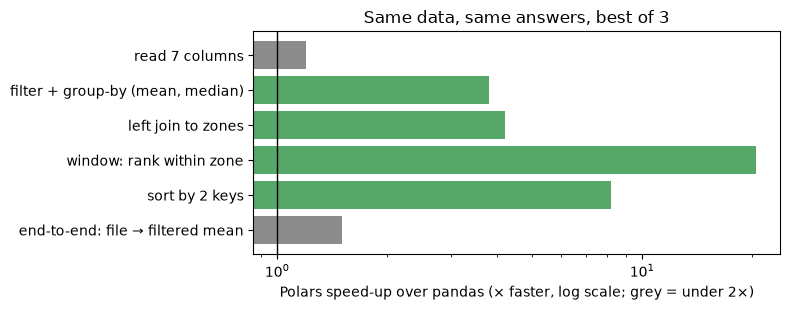

Large gains (≥2×): ['filter + group-by (mean, median)', 'left join to zones', 'window: rank within zone', 'sort by 2 keys']
Small or no gains (<2×): ['read 7 columns', 'end-to-end: file → filtered mean']
Why: pandas' read and simple aggregations already run in compiled code (pyarrow, Cython), so Polars' extra cores help less; window ranks and multi-key sorts are where single-threaded pandas falls far behind.


In [45]:
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.barh(results["operation"], results["speedup"], color=["#55A868" if s >= 2 else "#8C8C8C" for s in results["speedup"]])
ax.axvline(1, color="black", linewidth=1)
ax.set(xscale="log", xlabel="Polars speed-up over pandas (× faster, log scale; grey = under 2×)", title="Same data, same answers, best of 3")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

big = results.filter(pl.col("speedup") >= 2)["operation"].to_list()
small = results.filter(pl.col("speedup") < 2)["operation"].to_list()
print(f"Large gains (≥2×): {big}")
print(f"Small or no gains (<2×): {small}")
print("Why: pandas' read and simple aggregations already run in compiled code (pyarrow, Cython), so Polars' extra cores help less; "
      "window ranks and multi-key sorts are where single-threaded pandas falls far behind.")

**How to read this honestly:** every timing here is a fraction of a second on 3 M rows, so for a one-off analysis the difference rarely matters. It matters in pipelines that repeat these steps over many files or much bigger data — and there the lazy optimizer and streaming (sections 11–12) matter as much as raw speed.

> 💡 **Interview angle:** "Polars claims 10–50× over pandas — true?" — sometimes: it depends on the operation, data size, core count, and whether the comparison is fair (same columns, warm cache, equal results). Say you'd benchmark your own workload, like this section does.

## 🔧 Build It From Scratch

**Goal:** understand what a lazy engine really does by building a tiny one on top of pandas.

`MiniLazyFrame` **records** operations instead of running them. On `collect()`, an optimizer:
1. **Predicate pushdown** — moves each filter on an *original* column to the start and hands it to the Parquet reader (filters on columns we compute ourselves must stay after the computation).
2. **Projection pushdown** — walks the plan backwards to find which source columns are needed and reads only those.

Then we check the result against the equivalent Polars lazy query, and count how much data each plan read.

In [46]:
import operator

OPS = {">": operator.gt, ">=": operator.ge, "<": operator.lt, "<=": operator.le, "==": operator.eq}


class MiniLazyFrame:
    """A toy lazy DataFrame: records a plan, optimizes it, and executes it with pandas."""

    def __init__(self, path, plan=()):
        self.path, self.plan = Path(path), tuple(plan)

    def _add(self, step):
        return MiniLazyFrame(self.path, self.plan + (step,))

    # ── plan-building methods (nothing is read) ──
    def filter(self, column, op, value):
        return self._add(("filter", column, op, value))

    def with_column(self, name, fn, inputs):
        return self._add(("with_column", name, fn, tuple(inputs)))

    def select(self, *columns):
        return self._add(("select", tuple(columns)))

    def group_mean(self, key, column):
        return self._add(("group_mean", key, column))

    # ── optimizer ──
    def optimize(self):
        created = {s[1] for s in self.plan if s[0] == "with_column"}
        scan_filters = [s for s in self.plan if s[0] == "filter" and s[1] not in created]    # safe to push into the reader
        rest = [s for s in self.plan if s not in scan_filters]
        needed = set()                                                                      # walk backwards: which columns are used?
        for step in reversed(rest):
            kind = step[0]
            if kind == "group_mean":
                needed |= {step[1], step[2]}
            elif kind == "select":
                needed = set(step[1]) if not needed else needed & set(step[1]) | needed
            elif kind == "with_column":
                if step[1] in needed or not needed:
                    needed.discard(step[1])
                    needed |= set(step[3])
            elif kind == "filter":
                needed.add(step[1])
        needed |= {f[1] for f in scan_filters}
        source_columns = pq.read_schema(self.path).names
        columns = [c for c in source_columns if c in needed] or source_columns
        return columns, scan_filters, rest

    def explain(self, optimized=True):
        if not optimized:
            lines = [f"SCAN {self.path.name} (all columns)"] + [f"  {s[0]} {s[1:] if s[0] != 'with_column' else s[1]}" for s in self.plan]
        else:
            columns, scan_filters, rest = self.optimize()
            pushed = [(c, op, v) for _, c, op, v in scan_filters]
            lines = [f"SCAN {self.path.name} columns={columns} filters={pushed}"] + \
                    [f"  {s[0]} {s[1:] if s[0] != 'with_column' else s[1]}" for s in rest]
        return "\n".join(lines)

    # ── executor ──
    def collect(self, optimized=True):
        if optimized:
            columns, scan_filters, rest = self.optimize()
            filters = [(c, op, v) for _, c, op, v in scan_filters] or None
            df = pd.read_parquet(self.path, columns=columns, filters=filters)
        else:
            rest = self.plan
            df = pd.read_parquet(self.path)
        stats = {"rows_read": len(df), "columns_read": df.shape[1], "cells_read": df.size}
        for step in rest:
            kind = step[0]
            if kind == "filter":
                _, column, op, value = step
                df = df[OPS[op](df[column], value)]
            elif kind == "with_column":
                _, name, fn, inputs = step
                df = df.assign(**{name: fn(*(df[c] for c in inputs))})
            elif kind == "select":
                df = df[list(step[1])]
            elif kind == "group_mean":
                _, key, column = step
                df = df.groupby(key, as_index=False)[column].mean().sort_values(key, ignore_index=True)
        return df, stats


mini = (
    MiniLazyFrame(TRIPS_PATH)
    .with_column("tip_pct", lambda tip, fare: tip / fare, inputs=["tip_amount", "fare_amount"])
    .filter("payment_type", "==", 1)            # on a source column → pushable
    .filter("fare_amount", ">", 0)              # on a source column → pushable
    .filter("tip_pct", "<", 1.0)                # on a computed column → must stay after with_column
    .group_mean("PULocationID", "tip_pct")
)
print("── naive plan ──\n" + mini.explain(optimized=False))
print("\n── optimized plan ──\n" + mini.explain())

── naive plan ──
SCAN yellow_tripdata_2024-01.parquet (all columns)
  with_column tip_pct
  filter ('payment_type', '==', 1)
  filter ('fare_amount', '>', 0)
  filter ('tip_pct', '<', 1.0)
  group_mean ('PULocationID', 'tip_pct')

── optimized plan ──
SCAN yellow_tripdata_2024-01.parquet columns=['PULocationID', 'payment_type', 'fare_amount', 'tip_amount'] filters=[('payment_type', '==', 1), ('fare_amount', '>', 0)]
  with_column tip_pct
  filter ('tip_pct', '<', 1.0)
  group_mean ('PULocationID', 'tip_pct')


In [47]:
naive_df, naive_stats = mini.collect(optimized=False)
opt_df, opt_stats = mini.collect(optimized=True)

polars_df = (
    pl.scan_parquet(TRIPS_PATH)
    .with_columns(tip_pct=pl.col("tip_amount") / pl.col("fare_amount"))
    .filter((pl.col("payment_type") == 1) & (pl.col("fare_amount") > 0) & (pl.col("tip_pct") < 1.0))
    .group_by("PULocationID").agg(pl.col("tip_pct").mean())
    .sort("PULocationID")
    .collect()
)

assert naive_df["PULocationID"].tolist() == opt_df["PULocationID"].tolist() == polars_df["PULocationID"].to_list()
assert np.allclose(naive_df["tip_pct"], opt_df["tip_pct"]) and np.allclose(opt_df["tip_pct"], polars_df["tip_pct"].to_numpy())
print("✅ naive plan == optimized plan == Polars lazy query")
print(f"naive     read {naive_stats['rows_read']:>9,} rows × {naive_stats['columns_read']:>2} columns = {naive_stats['cells_read']:>11,} cells")
print(f"optimized read {opt_stats['rows_read']:>9,} rows × {opt_stats['columns_read']:>2} columns = {opt_stats['cells_read']:>11,} cells "
      f"→ {naive_stats['cells_read'] / opt_stats['cells_read']:.0f}× less data")

✅ naive plan == optimized plan == Polars lazy query
naive     read 2,964,624 rows × 19 columns =  56,327,856 cells
optimized read 2,318,858 rows ×  4 columns =   9,275,432 cells → 6× less data


Real optimizers do the same thing with far more rules: they reason about expressions (not just column names), reorder joins, push filters *through* joins and group-bys when that's safe, and combine repeated sub-plans. But the core idea is exactly this: **a recorded plan can be rewritten before any data is touched.**

## ⚠️ Common Pitfalls

### ❌ Pitfall 1 — Row-by-row Python functions (`map_elements`)

In [48]:
sample = raw.select("tip_amount").head(300_000)

with warnings.catch_warnings(record=True) as caught:        # capture the warning so we can print it
    warnings.simplefilter("always")
    start = time.perf_counter()
    slow = sample.select(pl.col("tip_amount").map_elements(lambda t: t * 100, return_dtype=pl.Float64))   # ❌ tip in cents, one Python call per row
    slow_s = time.perf_counter() - start
inefficient = [w for w in caught if type(w.message).__name__ == "PolarsInefficientMapWarning"]
if inefficient:
    print("❌ Polars warned (PolarsInefficientMapWarning):")
    print("\n".join("   " + line for line in str(inefficient[0].message).strip().splitlines()[2:]))
else:
    print("❌ (no PolarsInefficientMapWarning raised in this version)")

start = time.perf_counter()
fast = sample.select(pl.col("tip_amount") * 100)          # ✅ the expression Polars suggests
fast_s = time.perf_counter() - start
assert slow.equals(fast)
print(f"❌ map_elements: {slow_s * 1000:.0f} ms | ✅ expression: {fast_s * 1000:.1f} ms → {slow_s / fast_s:.0f}× faster, same result")

❌ Polars warned (PolarsInefficientMapWarning):
   Replace this expression...
     - pl.col("tip_amount").map_elements(lambda t: ...)
   with this one instead:
     + pl.col("tip_amount") * 100
❌ map_elements: 17 ms | ✅ expression: 0.2 ms → 102× faster, same result


### ❌ Pitfall 2 — Collecting too early (losing pushdown)

In [49]:
early = pl.scan_parquet(TRIPS_PATH).collect().lazy().filter(pl.col("payment_type") == 2).select("fare_amount")   # ❌
late = pl.scan_parquet(TRIPS_PATH).filter(pl.col("payment_type") == 2).select("fare_amount")                  # ✅
print("❌ early collect plan:\n" + early.explain())
print("\n✅ lazy until the end:\n" + late.explain())

❌ early collect plan:
simple π 1/1 ["fare_amount"]
  FILTER col("payment_type") == 2
  FROM
    DF ["VendorID", "tpep_pickup_datetime", "tpep_dropoff_datetime", "passenger_count", ...]; PROJECT["fare_amount", "payment_type"] 2/19 COLUMNS

✅ lazy until the end:
simple π 1/1 ["fare_amount"]
  Parquet SCAN [_outputs/nyc_taxi/yellow_tripdata_2024-01.parquet]
  PROJECT 2/19 COLUMNS
  SELECTION: col("payment_type") == 2
  ESTIMATED ROWS: 2964624


The first plan starts from an in-memory `DF` with all 19 columns: the whole file was read before the optimizer ever saw the filter.

### ❌ Pitfall 3 — Using a new column in the same context

In [50]:
try:
    raw.head(5).with_columns(duration=duration_min, speed=pl.col("trip_distance") / pl.col("duration"))   # ❌
except pl.exceptions.ColumnNotFoundError as err:
    print("❌ ColumnNotFoundError:", str(err).splitlines()[0])

ok = raw.head(5).with_columns(duration=duration_min).with_columns(speed=pl.col("trip_distance") / (pl.col("duration") / 60))   # ✅
print("✅ two contexts:", ok.select("duration", "speed").rows()[:2])

❌ ColumnNotFoundError: unable to find column "duration"; valid columns: ["VendorID", "tpep_pickup_datetime", "tpep_dropoff_datetime", "passenger_count", "trip_distance", "RatecodeID", "store_and_fwd_flag", "PULocationID", "DOLocationID", "payment_type", "fare_amount", "extra", "mta_tax", "tip_amount", "tolls_amount", "improvement_surcharge", "total_amount", "congestion_surcharge", "Airport_fee"]
✅ two contexts: [(19.8, 5.212121212121212), (6.6, 16.363636363636367)]


Expressions in one context run in parallel against the *input* frame, so `duration` doesn't exist yet. Chain a second `with_columns` (or reuse the expression variable).

### ❌ Pitfall 4 — Treating NaN like null

In [51]:
ratios = pl.DataFrame({"tip": [2.0, 0.0, 3.0], "fare": [10.0, 0.0, 12.0]}).select(r=pl.col("tip") / pl.col("fare"))
print("❌ fill_null(0) leaves the NaN:", ratios.select(pl.col("r").fill_null(0))["r"].to_list(), "→ mean", ratios.select(pl.col("r").fill_null(0).mean()).item())
print("✅ fill_nan(None) then aggregate:", ratios.select(pl.col("r").fill_nan(None).mean()).item())

❌ fill_null(0) leaves the NaN: [0.2, nan, 0.25] → mean nan
✅ fill_nan(None) then aggregate: 0.225


### ❌ Pitfall 5 — As-of join keys with different time units

In [52]:
snapshots = zone_hourly.select("PULocationID", "tpep_pickup_datetime", "trips_that_hour")
wrong_key = snapshots.with_columns(available_at=pl.col("tpep_pickup_datetime") + pl.duration(hours=1))     # ❌ changes ns → μs
print("dtypes:", trips_sorted.schema["tpep_pickup_datetime"], "vs", wrong_key.schema["available_at"])
try:
    trips_sorted.join_asof(wrong_key.sort("available_at"), left_on="tpep_pickup_datetime", right_on="available_at",
                           by="PULocationID", check_sortedness=False)
except pl.exceptions.SchemaError as err:
    print("❌ SchemaError:", str(err).splitlines()[0][:110])

right_key = snapshots.with_columns(available_at=pl.col("tpep_pickup_datetime").dt.offset_by("1h"))          # ✅ keeps ns
ok_join = trips_sorted.join_asof(right_key.sort("available_at"), left_on="tpep_pickup_datetime", right_on="available_at",
                                 by="PULocationID", check_sortedness=False, tolerance="1h")
print("✅ dt.offset_by keeps the unit:", right_key.schema["available_at"], "| joined rows:", f"{ok_join.height:,}")

dtypes: Datetime(time_unit='ns', time_zone=None) vs Datetime(time_unit='us', time_zone=None)
❌ SchemaError: datatypes of join keys don't match - `tpep_pickup_datetime`: datetime[ns] on left does not match `available_at
✅ dt.offset_by keeps the unit: Datetime(time_unit='ns', time_zone=None) | joined rows: 2,964,606


### ❌ Pitfall 6 — pandas habits on a Polars DataFrame (the old notebook's bug)

In [53]:
report = per_zone.head(3)
try:
    print(report.to_string())                                   # ❌ pandas-only method
except AttributeError as err:
    print("❌ AttributeError:", err)

with pl.Config(tbl_rows=3, tbl_hide_dataframe_shape=True):    # ✅ print directly, with display options scoped to this block
    print(report)
report.write_csv(OUTPUT_DIR / "per_zone_top3.csv")               # ✅ or write it out
print("✅ saved", OUTPUT_DIR / "per_zone_top3.csv")

❌ AttributeError: 'DataFrame' object has no attribute 'to_string'
┌──────────────┬────────┬──────────┬────────────┬────────────┬──────────────┐
│ PULocationID ┆ trips  ┆ avg_fare ┆ median_tip ┆ card_share ┆ avg_card_tip │
│ ---          ┆ ---    ┆ ---      ┆ ---        ┆ ---        ┆ ---          │
│ i32          ┆ u32    ┆ f64      ┆ f64        ┆ f64        ┆ f64          │
╞══════════════╪════════╪══════════╪════════════╪════════════╪══════════════╡
│ 132          ┆ 145240 ┆ 59.4     ┆ 9.94       ┆ 0.712      ┆ 12.39        │
│ 161          ┆ 143471 ┆ 15.21    ┆ 2.88       ┆ 0.802      ┆ 3.79         │
│ 237          ┆ 142708 ┆ 12.18    ┆ 2.5        ┆ 0.815      ┆ 3.12         │
└──────────────┴────────┴──────────┴────────────┴────────────┴──────────────┘
✅ saved _outputs/per_zone_top3.csv


Also different from pandas: there is **no index** (no `.loc`, no `set_index`), columns are selected with `df["col"]` or `select`, and there is no `inplace=True` — every operation returns a new DataFrame (cheap, because unchanged columns are shared, not copied).

## 🏋️ Practice Exercises

Try each one before opening the solution. Run the cell: ⏳ means not attempted, ✅ means correct. All use the real `raw` and `zones` tables.

### 🟢 Exercise 1 — Card share
What **fraction of all trips** in `raw` were paid by credit card (`payment_type == 1`)? Store a float in `card_share`.

In [54]:
card_share = None  # TODO
check("card_share", card_share, 0.7822395015354392, hint="The mean of a boolean expression is the share of True values.")

⏳ card_share: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
card_share = raw.select((pl.col("payment_type") == 1).mean()).item()
check("card_share", card_share, 0.7822395015354392)
```
</details>

### 🟢 Exercise 2 — Average card tip
What is the **mean `tip_amount`** of credit-card trips? (Cash tips aren't recorded, so tips only make sense for cards.) Store a float in `avg_card_tip`.

In [55]:
avg_card_tip = None  # TODO
check("avg_card_tip", avg_card_tip, 4.169670627490787, hint="filter payment_type == 1, then select the mean of tip_amount and .item()")

⏳ avg_card_tip: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
avg_card_tip = raw.filter(pl.col("payment_type") == 1).select(pl.col("tip_amount").mean()).item()
check("avg_card_tip", avg_card_tip, 4.169670627490787)
```
</details>

### 🟢 Exercise 3 — Median trip duration
Keep only pickups **in January 2024** (from 2024-01-01 inclusive to 2024-02-01 exclusive), then compute the **median trip duration in minutes** (fractional minutes, from the seconds between pickup and dropoff). Store a float in `median_duration_min`.

In [56]:
median_duration_min = None  # TODO
check("median_duration_min", median_duration_min, 11.633333333333333,
      hint="is_between(dt.datetime(2024, 1, 1), dt.datetime(2024, 2, 1), closed='left'), then (dropoff - pickup).dt.total_seconds() / 60")

⏳ median_duration_min: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
median_duration_min = (
    raw.filter(pl.col("tpep_pickup_datetime").is_between(dt.datetime(2024, 1, 1), dt.datetime(2024, 2, 1), closed="left"))
    .select(((pl.col("tpep_dropoff_datetime") - pl.col("tpep_pickup_datetime")).dt.total_seconds() / 60).median())
    .item()
)
check("median_duration_min", median_duration_min, 11.633333333333333)
```
`dt.total_minutes()` would truncate to whole minutes — dividing seconds by 60 keeps the fraction.
</details>

### 🟡 Exercise 4 — Top pickup boroughs
Join `raw` to `zones` to get each trip's **pickup borough**, then return the **top 3 boroughs by number of trips** as a DataFrame with columns `Borough, trips`, sorted by trips descending. Store it in `top_boroughs`.

In [57]:
top_boroughs = None  # TODO
check("top_boroughs", top_boroughs, [("Manhattan", 2_646_948), ("Queens", 273_128), ("Brooklyn", 25_258)],
      hint="raw.join(zones, left_on='PULocationID', right_on='LocationID', how='left').group_by('Borough').agg(trips=pl.len())...")

⏳ top_boroughs: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
top_boroughs = (
    raw.join(zones.select("LocationID", "Borough"), left_on="PULocationID", right_on="LocationID", how="left", validate="m:1")
    .group_by("Borough").agg(trips=pl.len())
    .sort("trips", descending=True)
    .head(3)
)
check("top_boroughs", top_boroughs, [("Manhattan", 2_646_948), ("Queens", 273_128), ("Brooklyn", 25_258)])
```
Yellow cabs are overwhelmingly a Manhattan (and airport) service: outer-borough street hails mostly go to green cabs and ride-hailing apps.
</details>

### 🟡 Exercise 5 — The cash hour
Among trips paid by **card or cash** (`payment_type` 1 or 2), which **pickup hour** has the **highest share of cash payments**? Store `(hour, cash_share)` in `peak_cash_hour`.

In [58]:
peak_cash_hour = None  # TODO
check("peak_cash_hour", peak_cash_hour, (5, 0.2143749219432996),
      hint="filter is_in([1, 2]); group_by(pl.col('tpep_pickup_datetime').dt.hour()) with agg((pl.col('payment_type') == 2).mean())")

⏳ peak_cash_hour: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
peak_cash_hour = (
    raw.filter(pl.col("payment_type").is_in([1, 2]))
    .group_by(hour=pl.col("tpep_pickup_datetime").dt.hour())
    .agg(cash_share=(pl.col("payment_type") == 2).mean())
    .sort("cash_share", descending=True)
    .row(0)
)
check("peak_cash_hour", peak_cash_hour, (5, 0.2143749219432996))
```
Early-morning riders (4–5 am) pay cash most often — about one trip in five.
</details>

### 🔴 Exercise 6 — Top-2 dropoff zones per borough (interview style)
Write **one lazy query** that returns, for pickup boroughs **Brooklyn, Manhattan, and Queens**, the **2 most common dropoff zones** (by zone *name*). Columns: `pu_borough, do_zone, trips, rank` (rank 1 = most trips; break ties by zone name A→Z), sorted by `pu_borough` then `rank`. Store the collected DataFrame in `top_dropoffs`.

In [59]:
top_dropoffs = None  # TODO
check("top_dropoffs", top_dropoffs,
      [("Brooklyn", "Crown Heights North", 683, 1), ("Brooklyn", "Park Slope", 660, 2),
       ("Manhattan", "Upper East Side North", 137_411, 1), ("Manhattan", "Upper East Side South", 126_521, 2),
       ("Queens", "Times Sq/Theatre District", 12_402, 1), ("Queens", "JFK Airport", 9_352, 2)],
      hint="Join pickup borough and dropoff zone name, group_by, sort by (borough, trips desc, zone), then pl.int_range(1, pl.len() + 1).over('pu_borough')")

⏳ top_dropoffs: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
zones_lf = pl.scan_csv(ZONES_PATH, schema_overrides={"LocationID": pl.Int32})
top_dropoffs = (
    pl.scan_parquet(TRIPS_PATH)
    .join(zones_lf.select(PULocationID="LocationID", pu_borough="Borough"), on="PULocationID")
    .join(zones_lf.select(DOLocationID="LocationID", do_zone="Zone"), on="DOLocationID")
    .filter(pl.col("pu_borough").is_in(["Brooklyn", "Manhattan", "Queens"]))
    .group_by("pu_borough", "do_zone").agg(trips=pl.len())
    .sort(["pu_borough", "trips", "do_zone"], descending=[False, True, False])
    .with_columns(rank=pl.int_range(1, pl.len() + 1).over("pu_borough"))
    .filter(pl.col("rank") <= 2)
    .collect()
)
check("top_dropoffs", top_dropoffs,
      [("Brooklyn", "Crown Heights North", 683, 1), ("Brooklyn", "Park Slope", 660, 2),
       ("Manhattan", "Upper East Side North", 137_411, 1), ("Manhattan", "Upper East Side South", 126_521, 2),
       ("Queens", "Times Sq/Theatre District", 12_402, 1), ("Queens", "JFK Airport", 9_352, 2)])
```

Sorting with the tiebreaker first, then numbering rows inside each partition, makes the ranking **deterministic**. `rank("ordinal")` alone would break ties by input order, which isn't guaranteed after a parallel group-by.
</details>

## 🚀 Mini Project: A Lazy Analytics Pipeline on NYC Taxi Trips

**Goal:** turn the raw January 2024 trip file into trustworthy answers with **one lazy pipeline**: audit data quality → apply explicit cleaning rules → join zone names → add window features → aggregate → **cross-check against DuckDB** → report findings computed from the data.

**Questions:** When is each borough busiest? How do airport trips differ from the rest? Which routes dominate, and how much do card riders tip?

### Step 1 — Audit data quality (one lazy pass)

Every rule is a boolean expression. Summing booleans counts violations; Polars computes all counts in a single scan.

In [60]:
trips_lf = pl.scan_parquet(TRIPS_PATH)
zones_lf = pl.scan_csv(ZONES_PATH, schema_overrides={"LocationID": pl.Int32})

duration = (pl.col("tpep_dropoff_datetime") - pl.col("tpep_pickup_datetime")).dt.total_seconds() / 60
RULES = {
    "pickup outside Jan 2024": ~pl.col("tpep_pickup_datetime").is_between(dt.datetime(2024, 1, 1), dt.datetime(2024, 2, 1), closed="left"),
    "duration not in 1–180 min": ~duration.is_between(1, 180),
    "distance not in (0, 100] mi": ~((pl.col("trip_distance") > 0) & (pl.col("trip_distance") <= 100)),
    "fare or total ≤ 0": (pl.col("fare_amount") <= 0) | (pl.col("total_amount") <= 0),
    "speed > 80 mph": (pl.col("trip_distance") / (duration / 60)) > 80,
    "unknown zone (264/265)": pl.col("PULocationID").is_in([264, 265]) | pl.col("DOLocationID").is_in([264, 265]),
}
audit = trips_lf.select(total=pl.len(), **{name: rule.sum() for name, rule in RULES.items()}).collect()
audit_long = audit.drop("total").transpose(include_header=True, header_name="rule", column_names=["rows"]).with_columns(
    share=(pl.col("rows") / audit["total"].item()).round(4))
print(f"total rows: {audit['total'].item():,}")
audit_long

total rows: 2,964,624


rule,rows,share
str,u32,f64
"""pickup outside Jan 2024""",18,0.0
"""duration not in 1–180 min""",37104,0.0125
"""distance not in (0, 100] mi""",60430,0.0204
"""fare or total ≤ 0""",38341,0.0129
"""speed > 80 mph""",1921,0.0006
"""unknown zone (264/265)""",31527,0.0106


### Step 2 — Clean with explicit rules

A trip is kept only if it breaks **no** rule. Rules overlap (a zero-distance trip often has a zero fare too), so we count the kept rows directly instead of subtracting.

In [61]:
def clean(lf):
    any_violation = pl.any_horizontal(list(RULES.values()))
    return lf.filter(~any_violation.fill_null(True))     # a null in any rule's input counts as a violation


clean_count = clean(trips_lf).select(pl.len()).collect().item()
total_rows = audit["total"].item()
print(f"kept {clean_count:,} of {total_rows:,} trips ({clean_count / total_rows:.1%}); removed {total_rows - clean_count:,}")

kept 2,831,302 of 2,964,624 trips (95.5%); removed 133,322


### Step 3 — Join zones and engineer features

In [62]:
AIRPORT_ZONES = [1, 132, 138]                              # Newark, JFK, LaGuardia

features_lf = (
    clean(trips_lf)
    .join(zones_lf.select(PULocationID="LocationID", pu_borough="Borough", pu_zone="Zone"), on="PULocationID", how="left", validate="m:1")
    .join(zones_lf.select(DOLocationID="LocationID", do_borough="Borough", do_zone="Zone"), on="DOLocationID", how="left", validate="m:1")
    .with_columns(
        duration_min=duration,
        hour=pl.col("tpep_pickup_datetime").dt.hour(),
        is_weekend=pl.col("tpep_pickup_datetime").dt.weekday() >= 6,
        is_airport=pl.col("PULocationID").is_in(AIRPORT_ZONES) | pl.col("DOLocationID").is_in(AIRPORT_ZONES),
        tip_pct=pl.when(pl.col("payment_type") == 1).then(pl.col("tip_amount") / pl.col("fare_amount")),   # null for non-card
    )
    .with_columns(speed_mph=pl.col("trip_distance") / (pl.col("duration_min") / 60))
)
print(features_lf.collect_schema().names())

['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee', 'pu_borough', 'pu_zone', 'do_borough', 'do_zone', 'duration_min', 'hour', 'is_weekend', 'is_airport', 'tip_pct', 'speed_mph']


### Step 4 — Window features

- `zone_hour_trips`: how many pickups happened in the same zone and clock hour (a demand signal).
- `fare_vs_route_median`: this fare divided by the median fare of the same pickup→dropoff route (spots unusual fares).
- `route_trips`: how common the route is.

In [63]:
windowed_lf = features_lf.with_columns(
    zone_hour_trips=pl.len().over("PULocationID", pl.col("tpep_pickup_datetime").dt.truncate("1h")),
    fare_vs_route_median=pl.col("fare_amount") / pl.col("fare_amount").median().over("PULocationID", "DOLocationID"),
    route_trips=pl.len().over("PULocationID", "DOLocationID"),
)

features_path = OUTPUT_DIR / "trips_features_2024-01.parquet"
windowed_lf.sink_parquet(features_path)                    # streams the enriched trips to disk
enriched_clean = pl.scan_parquet(features_path)            # later queries start from the saved features
print(f"saved {enriched_clean.select(pl.len()).collect().item():,} enriched trips → {features_path} ({features_path.stat().st_size / 1e6:.0f} MB)")
enriched_clean.select("pu_zone", "do_zone", "fare_amount", "zone_hour_trips", "fare_vs_route_median", "route_trips").head(3).collect()

saved 2,831,302 enriched trips → _outputs/trips_features_2024-01.parquet (104 MB)


pu_zone,do_zone,fare_amount,zone_hour_trips,fare_vs_route_median,route_trips
str,str,f64,u32,f64,u32
"""Penn Station/Madison Sq West""","""East Village""",17.7,100,1.134615,2630
"""Lenox Hill East""","""Upper East Side North""",10.0,88,0.934579,6020
"""Upper East Side North""","""East Village""",23.3,160,0.89272,420


### Step 5 — Aggregations (several lazy queries, collected together)

`pl.collect_all` runs several lazy queries in one go, so Polars can share work between them.

In [64]:
hourly_q = (enriched_clean.filter(pl.col("pu_borough").is_in(["Manhattan", "Queens", "Brooklyn"]))
            .group_by("pu_borough", "hour").agg(trips=pl.len()).sort("pu_borough", "hour"))
airport_q = (enriched_clean.group_by("is_airport")
             .agg(trips=pl.len(), avg_fare=pl.col("fare_amount").mean(), avg_distance=pl.col("trip_distance").mean(),
                  avg_minutes=pl.col("duration_min").mean(), card_tip_pct=pl.col("tip_pct").mean())
             .sort("is_airport"))
routes_q = (enriched_clean.group_by("pu_zone", "do_zone")
            .agg(trips=pl.len(), median_fare=pl.col("fare_amount").median())
            .sort(["trips", "pu_zone", "do_zone"], descending=[True, False, False]).head(5))
tips_q = (enriched_clean.filter(pl.col("tip_pct").is_not_null())
          .group_by("pu_borough").agg(card_trips=pl.len(), median_tip_pct=pl.col("tip_pct").median(),
                                      zero_tip_share=(pl.col("tip_amount") == 0).mean())
          .filter(pl.col("card_trips") >= 1000).sort("median_tip_pct", descending=True))

hourly, airport, routes, tips = pl.collect_all([hourly_q, airport_q, routes_q, tips_q])
print(airport.with_columns(cs.float().round(3)))
print(routes)
print(tips.with_columns(cs.float().round(3)))

shape: (2, 6)
┌────────────┬─────────┬──────────┬──────────────┬─────────────┬──────────────┐
│ is_airport ┆ trips   ┆ avg_fare ┆ avg_distance ┆ avg_minutes ┆ card_tip_pct │
│ ---        ┆ ---     ┆ ---      ┆ ---          ┆ ---         ┆ ---          │
│ bool       ┆ u32     ┆ f64      ┆ f64          ┆ f64         ┆ f64          │
╞════════════╪═════════╪══════════╪══════════════╪═════════════╪══════════════╡
│ false      ┆ 2558413 ┆ 14.251   ┆ 2.151        ┆ 12.872      ┆ 0.261        │
│ true       ┆ 272889  ┆ 54.642   ┆ 13.457       ┆ 34.086      ┆ 0.218        │
└────────────┴─────────┴──────────┴──────────────┴─────────────┴──────────────┘
shape: (5, 4)
┌───────────────────────┬───────────────────────┬───────┬─────────────┐
│ pu_zone               ┆ do_zone               ┆ trips ┆ median_fare │
│ ---                   ┆ ---                   ┆ ---   ┆ ---         │
│ str                   ┆ str                   ┆ u32   ┆ f64         │
╞═══════════════════════╪═══════════════════

### Step 6 — Cross-check against DuckDB

A second engine, written in a different language (SQL), must reproduce the key numbers from the same Parquet file with the same rules. If they disagree, one pipeline has a bug.

In [65]:
duck = duckdb.connect()
duck_hourly = duck.sql(f"""
    WITH t AS (
        SELECT *, date_diff('second', tpep_pickup_datetime, tpep_dropoff_datetime) / 60.0 AS duration_min
        FROM read_parquet('{TRIPS_PATH}')
    )
    SELECT z.Borough AS pu_borough, hour(t.tpep_pickup_datetime) AS hour, COUNT(*) AS trips
    FROM t JOIN read_csv('{ZONES_PATH}') AS z ON z.LocationID = t.PULocationID
    WHERE t.tpep_pickup_datetime >= TIMESTAMP '2024-01-01' AND t.tpep_pickup_datetime < TIMESTAMP '2024-02-01'
      AND t.duration_min BETWEEN 1 AND 180
      AND t.trip_distance > 0 AND t.trip_distance <= 100
      AND t.fare_amount > 0 AND t.total_amount > 0
      AND t.trip_distance / (t.duration_min / 60) <= 80
      AND t.PULocationID NOT IN (264, 265) AND t.DOLocationID NOT IN (264, 265)
      AND z.Borough IN ('Manhattan', 'Queens', 'Brooklyn')
    GROUP BY ALL ORDER BY pu_borough, hour
""").pl()

assert_frame_equal(hourly, duck_hourly, check_dtypes=False)
duck_total = duck.sql(f"""
    SELECT COUNT(*) FROM read_parquet('{TRIPS_PATH}')
    WHERE tpep_pickup_datetime >= TIMESTAMP '2024-01-01' AND tpep_pickup_datetime < TIMESTAMP '2024-02-01'
      AND date_diff('second', tpep_pickup_datetime, tpep_dropoff_datetime) BETWEEN 60 AND 10800
      AND trip_distance > 0 AND trip_distance <= 100 AND fare_amount > 0 AND total_amount > 0
      AND trip_distance / (date_diff('second', tpep_pickup_datetime, tpep_dropoff_datetime) / 3600.0) <= 80
      AND PULocationID NOT IN (264, 265) AND DOLocationID NOT IN (264, 265)
""").fetchone()[0]
assert duck_total == clean_count, (duck_total, clean_count)
print(f"✅ DuckDB reproduces the cleaned row count ({duck_total:,}) and all {hourly.height} borough × hour counts exactly")

✅ DuckDB reproduces the cleaned row count (2,831,302) and all 72 borough × hour counts exactly


### Step 7 — Results and findings

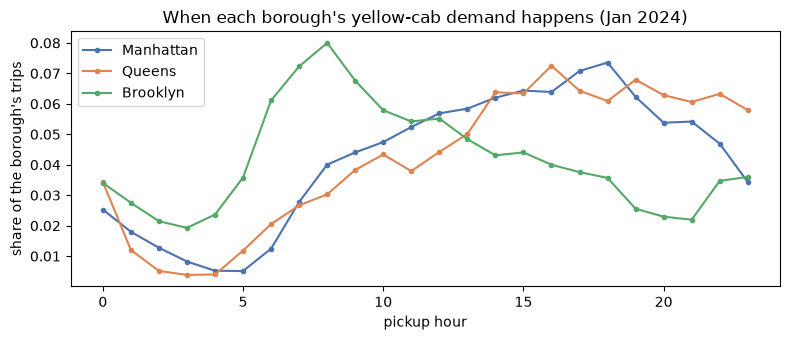

In [66]:
fig, ax = plt.subplots(figsize=(8, 3.5))
for borough, color in [("Manhattan", "#4C72B0"), ("Queens", "#DD8452"), ("Brooklyn", "#55A868")]:
    part = hourly.filter(pl.col("pu_borough") == borough)
    ax.plot(part["hour"], part["trips"] / part["trips"].sum(), marker="o", markersize=3, label=borough, color=color)
ax.set(xlabel="pickup hour", ylabel="share of the borough's trips", title="When each borough's yellow-cab demand happens (Jan 2024)")
ax.legend()
plt.tight_layout()
plt.show()

In [67]:
peak = hourly.sort("trips", descending=True).group_by("pu_borough", maintain_order=True).first().sort("pu_borough")
air, non_air = airport.filter(pl.col("is_airport")).row(0, named=True), airport.filter(~pl.col("is_airport")).row(0, named=True)
top_route = routes.row(0, named=True)
best_tip, worst_tip = tips.row(0, named=True), tips.row(-1, named=True)
airport_share = air["trips"] / (air["trips"] + non_air["trips"])

print(f"1. Data quality: {total_rows - clean_count:,} of {total_rows:,} trips ({1 - clean_count / total_rows:.1%}) broke at least one rule; "
      f"the most common problem was '{audit_long.sort('rows', descending=True)['rule'][0]}'.")
print("2. Peak hours: " + "; ".join(f"{r['pu_borough']} at {r['hour']}:00" for r in peak.iter_rows(named=True)) + ".")
print(f"3. Airports: {airport_share:.1%} of clean trips start or end at an airport, with an average fare of ${air['avg_fare']:.2f} "
      f"vs ${non_air['avg_fare']:.2f} ({air['avg_fare'] / non_air['avg_fare']:.1f}×) and {air['avg_distance']:.1f} vs {non_air['avg_distance']:.1f} miles.")
print(f"4. Busiest route: {top_route['pu_zone']} → {top_route['do_zone']} ({top_route['trips']:,} trips, median fare ${top_route['median_fare']:.2f}).")
print(f"5. Card tips: median tip is {best_tip['median_tip_pct']:.1%} of the fare for {best_tip['pu_borough']} pickups vs "
      f"{worst_tip['median_tip_pct']:.1%} for {worst_tip['pu_borough']}; {worst_tip['zero_tip_share']:.1%} of {worst_tip['pu_borough']} card trips tipped nothing.")

1. Data quality: 133,322 of 2,964,624 trips (4.5%) broke at least one rule; the most common problem was 'distance not in (0, 100] mi'.
2. Peak hours: Brooklyn at 8:00; Manhattan at 18:00; Queens at 16:00.
3. Airports: 9.6% of clean trips start or end at an airport, with an average fare of $54.64 vs $14.25 (3.8×) and 13.5 vs 2.2 miles.
4. Busiest route: Upper East Side South → Upper East Side North (21,615 trips, median fare $8.60).
5. Card tips: median tip is 26.6% of the fare for Manhattan pickups vs 0.0% for Brooklyn; 69.1% of Brooklyn card trips tipped nothing.


**Stretch goals**
1. Add the **previous-hour zone demand** feature from section 7 with `join_asof` and check how well it predicts `zone_hour_trips`.
2. Scan **three months** at once (`pl.scan_parquet([...])`) and run the pipeline with `engine="streaming"`; measure peak memory with `run_in_fresh_process`.
3. Flag trips whose `fare_vs_route_median` is above 3 on routes with ≥ 100 trips and inspect them: fraud, tolls, or data errors?
4. Wrap each step in a function and write **unit tests** with small hand-made DataFrames and `assert_frame_equal`.

### 🗣️ How to talk about this in an interview
- "I built the whole pipeline lazily on 3 M real trips, so Polars pushed column selection and filters into the Parquet scan; `explain()` confirmed it read only the columns each query needed."
- "Cleaning rules were explicit boolean expressions, and I audited how many rows each rule removed before filtering — about 5% of trips broke at least one rule."
- "Joins to the zone lookup used IDs with `validate='m:1'`, because zone names are duplicated in the lookup and would silently multiply rows."
- "I validated the pipeline against an independent DuckDB SQL implementation: identical cleaned row counts and borough × hour aggregates."
- "For data bigger than RAM I'd keep the same code and switch to the streaming engine and `sink_parquet`; only if one machine isn't enough would I move to Spark or Dask."

## 🎤 Interview Q&A

Try answering **out loud** before opening each answer.

### 🧠 Concepts

**Q1. Why is Polars often faster than pandas?**

<details><summary>Show answer</summary>

- **30-second answer:** It stores data in Arrow columnar memory, its Rust engine runs operations across all CPU cores, and its lazy API lets a query optimizer remove unnecessary work (projection/predicate pushdown, expression simplification) before execution.
- **Go deeper:** pandas' core ops are also compiled, so the gap is small for simple reads and aggregations and large for multi-threadable work like sorts, joins, and window functions. Polars has no index and no Python-object columns by default, avoiding alignment and boxing overhead. Always benchmark fairly: same columns, warm cache, equal results.
- **❌ Common wrong answer:** "Because Rust is faster than Python." pandas' hot loops aren't in Python either — the architecture (threads, columnar engine, optimizer) is what matters.

</details>

**Q2. What is lazy evaluation, and when should you call `collect()`?**

<details><summary>Show answer</summary>

- **30-second answer:** Lazy evaluation builds a query plan without running it; `collect()` optimizes and executes the whole plan. Stay lazy from `scan_*` through filters, joins, and aggregations, and collect once at the end, when the result is small.
- **Go deeper:** Collecting early (`scan → collect → filter`) throws away pushdown because the optimizer can't see past the materialized frame. Use `collect_all` for several queries over the same inputs, `explain()` to verify the plan, and `sink_*` when the output itself is large.
- **❌ Common wrong answer:** "Lazy is just slower eager" or "collect after every step to check the data" — use `.head().collect()` or `explain()` for inspection instead.

</details>

**Q3. Explain predicate pushdown and projection pushdown.**

<details><summary>Show answer</summary>

- **30-second answer:** Predicate pushdown moves filters as close to the data source as possible so fewer rows are read; projection pushdown reads only the columns the query uses. Both reduce I/O, decoding, and memory.
- **Go deeper:** With Parquet, predicate pushdown can skip whole row groups using min/max statistics — but only if the file has them (these TLC files don't, so rows are filtered during decoding instead). Filters can be pushed through joins only when semantics allow (e.g. a filter on the right table of a left join can't simply be moved below it). The same ideas exist in Spark, DuckDB, and warehouses.
- **❌ Common wrong answer:** "Pushdown means filtering happens on the GPU" or "it only applies to databases, not files."

</details>

**Q4. What's the difference between `select`, `with_columns`, and `group_by().agg()`?**

<details><summary>Show answer</summary>

- **30-second answer:** `select` returns only the expressions you list; `with_columns` adds or replaces columns and keeps the rest; `group_by().agg()` evaluates expressions per group and returns one row per group.
- **Go deeper:** Expressions within a single context run in parallel against the input, so a column created in a context can't be referenced in the same context. Aggregations inside `select` broadcast when mixed with full-length columns only in `with_columns`/`over` style usage — otherwise lengths must match.
- **❌ Common wrong answer:** "`with_columns` modifies the DataFrame in place." Polars DataFrames are immutable; every method returns a new frame (sharing unchanged column buffers).

</details>

**Q5. null vs NaN in Polars — what's the difference and why does it matter?**

<details><summary>Show answer</summary>

- **30-second answer:** null means missing (any dtype, tracked in a validity bitmap, skipped by aggregations); NaN is a floating-point value from invalid math that propagates through `mean` and `sum`. `fill_null` does not touch NaN.
- **Go deeper:** `0/0` gives NaN and `x/0` gives ±inf, so ratio features need `is_finite()` or `fill_nan(None)`. `pl.from_pandas` converts NaN to null by default (`nan_to_null=True`). In pandas both were historically NaN, which is why ported code often mishandles missing values.
- **❌ Common wrong answer:** "They're the same thing, Polars just prints them differently."

</details>

**Q6. When would you choose pandas, DuckDB, Polars, or Spark?**

<details><summary>Show answer</summary>

- **30-second answer:** pandas for small data and maximum ecosystem compatibility; DuckDB when SQL is the natural interface or for ad hoc queries over Parquet; Polars for Python data pipelines on a single machine up to roughly the size of local disk (streaming); Spark (or Dask) when data or compute must span a cluster.
- **Go deeper:** DuckDB and Polars share columnar, vectorized, multi-threaded designs and interoperate through Arrow — many teams use both. Distributed systems add shuffle costs, cluster operations, and failure handling, so "scale up before scaling out" is usually cheaper.
- **❌ Common wrong answer:** "Always Spark for anything over 1 GB." A single modern machine handles tens of GB comfortably.

</details>

**Q7. What is an as-of join and why is it important for ML?**

<details><summary>Show answer</summary>

- **30-second answer:** It joins each row to the most recent (backward), next (forward), or nearest row of another table by an ordered key, usually time, optionally within groups. It's how you attach the feature values that were known at prediction time — point-in-time correctness.
- **Go deeper:** Join on when the feature became *available*, not the period it describes; use `tolerance` to expire stale values and `allow_exact_matches=False` if equal timestamps shouldn't count. Both sides must be sorted by the key within groups. Feature stores (Feast, Tecton, Databricks) implement exactly this for training sets.
- **❌ Common wrong answer:** "Just join on the date and take the latest value" — that often includes values recorded later the same day, which leaks the future.

</details>

### 💻 Coding

**Q8. Return the top 3 zones by trips within each borough in Polars.**

<details><summary>Show answer</summary>

- **30-second answer:** `df.group_by("borough", "zone").agg(trips=pl.len()).filter(pl.col("trips").rank("ordinal", descending=True).over("borough") <= 3).sort("borough", "trips", descending=[False, True])`.
- **Go deeper:** Decide how to treat ties: `rank("dense")` keeps all tied rows, `"ordinal"` keeps exactly 3. For deterministic tiebreaks, sort by (group, value, tiebreaker) and number rows with `pl.int_range(1, pl.len() + 1).over("borough")`. The same pattern in SQL is `ROW_NUMBER() OVER (PARTITION BY …)` with `QUALIFY`.
- **❌ Common wrong answer:** `.sort("trips").head(3)` — that's 3 rows overall, not per borough.

</details>

**Q9. For each user event, add the time since that user's previous event.**

<details><summary>Show answer</summary>

- **30-second answer:** `df.with_columns(gap=pl.col("ts").diff().over("user_id", order_by="ts"))` — or sort by `(user_id, ts)` first and use `.diff().over("user_id")`.
- **Go deeper:** The first event per user gets null — decide whether to leave it or fill it. Use `.dt.total_seconds()` to turn the duration into a number, and `shift(1)` instead of `diff` when you need the previous *value* rather than the gap.
- **❌ Common wrong answer:** `pl.col("ts").diff()` without `over` — it subtracts across different users at the boundaries.

</details>

**Q10. Convert this pandas code to idiomatic Polars: `df["ratio"] = df.apply(lambda r: r.a / r.b if r.b else None, axis=1)`.**

<details><summary>Show answer</summary>

- **30-second answer:** `df = df.with_columns(ratio=pl.when(pl.col("b") != 0).then(pl.col("a") / pl.col("b")))` — a vectorized conditional; rows where the condition is false become null.
- **Go deeper:** `map_elements` would work but runs Python per row (Polars warns with `PolarsInefficientMapWarning`) and blocks optimization and parallelism. There's no in-place assignment in Polars; you reassign the returned frame.
- **❌ Common wrong answer:** `df["ratio"] = ...` — Polars doesn't support item assignment on DataFrames, and `apply` row-wise defeats the engine.

</details>

### 🐛 Debugging Scenarios

**Q11. A Polars job reading a 30 GB Parquet dataset gets killed for running out of memory. What do you check?**

<details><summary>Show answer</summary>

- **30-second answer:** Whether it uses `read_parquet` or collects early (materializing everything); switch to `scan_parquet`, select only needed columns, filter early, aggregate before collecting, and use `collect(engine="streaming")` or `sink_parquet` for large outputs.
- **Go deeper:** Check `explain()` for pushdown, look for operations that force full materialization (huge joins producing big outputs, `pivot`, some sorts), reduce dtypes (`Int32`, `Categorical`), and process partitions/files one at a time if needed. Measure peak RSS as you change things.
- **❌ Common wrong answer:** "Buy a bigger machine" or "switch to Spark" before fixing an eager read of all columns.

</details>

**Q12. After joining trips to a zone table, total revenue went up by 3%. What happened and how do you prevent it?**

<details><summary>Show answer</summary>

- **30-second answer:** The right-side key wasn't unique (e.g. joining on zone *name*, which repeats), so some trips matched several rows and were duplicated. Join on a unique ID, and pass `validate="m:1"` so Polars raises instead of duplicating.
- **Go deeper:** Assert row counts before and after left joins, check `df["key"].is_unique().all()` on dimension tables, and aggregate the many-side before joining when you need one row per key.
- **❌ Common wrong answer:** "Call `unique()` on the result" — it hides the bug and may drop legitimate identical rows.

</details>

**Q13. `with_columns(a=..., b=pl.col("a") * 2)` raises `ColumnNotFoundError`. Why?**

<details><summary>Show answer</summary>

- **30-second answer:** All expressions in one context are evaluated in parallel against the *input* frame, where `a` doesn't exist yet. Split into two `with_columns` calls or reuse the expression object for `a`.
- **Go deeper:** This parallel design is what lets Polars compute many columns at once; the optimizer may still merge consecutive contexts when it's safe (`cluster_with_columns`).
- **❌ Common wrong answer:** "It's a bug in Polars" or "you must `collect()` in between."

</details>

### 🏗️ Design

**Q14. Design a daily feature pipeline over 200 GB of new Parquet event data. Would you use Polars?**

<details><summary>Show answer</summary>

- **30-second answer:** Probably yes for a single-node job if the daily *incremental* data and per-day aggregations fit: partition input by date, `scan_parquet` only the new partitions (hive partitioning), compute features lazily with streaming, `sink_parquet` to a date-partitioned feature table, and validate row counts and nulls before publishing. If the job needs cross-history shuffles over terabytes or a shared cluster already exists, Spark is the safer choice.
- **Go deeper:** Keep feature definitions as reusable expression functions (shared by training and serving), use point-in-time joins for training sets, make runs idempotent (overwrite a date partition), and monitor runtime and peak memory. Cross-check a sample against an independent implementation (e.g. DuckDB SQL), as in the mini project.
- **❌ Common wrong answer:** "Load all history into a DataFrame every day and recompute everything."

</details>

## 🧪 Quick Quiz

Predict the output, then reveal.

**1.** `pl.DataFrame({"a": [1, 2, 3]}).with_columns(b=pl.col("a") * 2, c=pl.col("a").sum())` — what is column `c`?
<details><summary>Answer</summary>

`[6, 6, 6]` — an aggregation inside `with_columns` produces one value, which is broadcast to every row.
</details>

**2.** `pl.Series([1.0, None, float("nan")]).mean()`
<details><summary>Answer</summary>

`nan` — the null is skipped, but NaN is a float value and poisons the mean.
</details>

**3.** `pl.Series([1, None, 3]).mean()`
<details><summary>Answer</summary>

`2.0` — nulls are ignored by aggregations.
</details>

**4.** `pl.DataFrame({"g": ["x", "x", "y"], "v": [1, 2, 3]}).select(pl.col("v").sum().over("g"))` — which values?
<details><summary>Answer</summary>

`[3, 3, 3]` — group `x` sums to 3 and group `y` is 3; `over` broadcasts each group's result back to its rows.
</details>

**5.** How many rows does `pl.scan_parquet("trips.parquet").filter(pl.col("fare_amount") > 0).head(5)` read from disk when this line runs?
<details><summary>Answer</summary>

**None** — it returns a `LazyFrame` (a plan). Data is read only when you call `.collect()`, and then the slice pushdown stops early.
</details>

## 📚 Resources

### 📖 Official Docs
- [Getting started - Polars user guide](https://docs.pola.rs/user-guide/getting-started/) — the official 10-minute tour
- [Expressions and contexts - Polars user guide](https://docs.pola.rs/user-guide/concepts/expressions-and-contexts/) — the mental model behind every section here
- [Lazy API - Polars user guide](https://docs.pola.rs/user-guide/concepts/lazy-api/) · [Optimizations - Polars user guide](https://docs.pola.rs/user-guide/lazy/optimizations/) · [Streaming - Polars user guide](https://docs.pola.rs/user-guide/concepts/streaming/)
- [Window functions - Polars user guide](https://docs.pola.rs/user-guide/expressions/window-functions/) · [Joins - Polars user guide](https://docs.pola.rs/user-guide/transformations/joins/) · [polars.DataFrame.join_asof — Polars documentation](https://docs.pola.rs/api/python/stable/reference/dataframe/api/polars.DataFrame.join_asof.html)
- [Missing data - Polars user guide](https://docs.pola.rs/user-guide/expressions/missing-data/) — null vs NaN in detail
- [Coming from Pandas - Polars user guide](https://docs.pola.rs/user-guide/migration/pandas/) · [Comparison with other tools - Polars user guide](https://docs.pola.rs/user-guide/misc/comparison/)
- [Arrow Columnar Format — Apache Arrow](https://arrow.apache.org/docs/format/Columnar.html) — how columns, validity bitmaps, and buffers are laid out
- Dataset: [TLC Trip Record Data - TLC](https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page) · [Data Dictionary – Yellow Taxi Trip Records (PDF)](https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf)

### 🎥 Videos
- [Rob Mulla — Polars: The Next Big Python Data Science Library... written in RUST?](https://www.youtube.com/watch?v=VHqn7ufiilE) (14 m) — a quick, beginner-friendly tour with pandas comparisons; watch it first
- [PyData — Ritchie Vink - Polars and a peek into the expression engine | PyData Amsterdam 2023](https://www.youtube.com/watch?v=NJbBWDzZuWs) (24 m) — Polars' creator explains how expressions are optimized and run in parallel (sections 3 and 11)
- [PyData — Ritchie Vink - Polars; DataFrames in the multi-core era | PyData NYC 2023](https://www.youtube.com/watch?v=tqcudsykOGc) (44 m) — the design choices behind the speed: Arrow memory, multithreading, lazy optimizations, and streaming

### 📄 Papers
- [Boncz, Zukowski & Nes (2005) — MonetDB/X100: Hyper-Pipelining Query Execution (CIDR)](https://www.cidrdb.org/cidr2005/papers/P19.pdf) — the origin of vectorized, column-at-a-time execution used by Polars and DuckDB
- [Leis et al. (2014) — Morsel-Driven Parallelism: A NUMA-Aware Query Evaluation Framework for the Many-Core Age (SIGMOD)](https://db.in.tum.de/~leis/papers/morsels.pdf) — how modern engines split work into small batches across cores

### 📘 Books & Courses
- [Modern Polars](https://kevinheavey.github.io/modern-polars/) — Kevin Heavey's free book translating idiomatic pandas into Polars side by side
- [Coming from Pandas - Polars user guide](https://docs.pola.rs/user-guide/migration/pandas/) — the official migration chapter, worth reading end to end

### 🏋️ Practice
- [Database-like ops benchmark](https://duckdblabs.github.io/db-benchmark/) — standard group-by and join benchmark questions; re-implement a few in Polars and pandas and time them with the rules from section 14
- [TLC Trip Record Data - TLC](https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page) — pick another month or the green-taxi / for-hire-vehicle files and rebuild the mini project

## 📝 Summary Cheat Sheet

| Concept | What it does | Key API |
|---|---|---|
| Read data | eager load / lazy scan | `pl.read_parquet`, `pl.read_csv(schema_overrides=…)`, `pl.scan_parquet`, `pl.scan_csv` |
| Expressions | column recipes | `pl.col`, `pl.lit`, `.alias`, selectors `cs.float()` |
| Contexts | where expressions run | `select`, `with_columns`, `filter`, `group_by().agg()` |
| Conditions | vectorized if/else | `pl.when().then().otherwise()`, `replace_strict(mapping, default=…)` |
| Joins | combine tables | `join(how="left"/"semi"/"anti", validate="m:1")` |
| As-of join | point-in-time lookups | `join_asof(left_on, right_on, by=…, strategy="backward", tolerance=…)` |
| Windows | per-group values on every row | `expr.over("g")`, `over("g", order_by="ts")`, `rank`, `diff`, `shift`, `int_range().over()` |
| Types | text, time, nested | `.str.contains/split`, `.dt.hour/truncate/offset_by`, `group_by_dynamic`, `.list.len/mean`, `unnest` |
| Missing | null vs NaN | `is_null/fill_null` vs `is_nan/fill_nan`, `is_finite()` |
| Lazy plans | optimize before running | `explain(optimized=False/True)`, `collect()`, `collect_all()`, `profile()` |
| Out-of-core | batches instead of all at once | `collect(engine="streaming")`, `sink_parquet`, `collect_batches()` |
| Interop | move data between tools | `to_pandas()`, `pl.from_pandas()`, `to_numpy()`, `to_arrow()`, DuckDB `FROM df` + `.pl()`, `df.sql()` |
| Benchmarks | fair comparisons | same columns, best of N, assert equal results, report hardware |

## ➡️ What's Next

**[02 · PySpark](02_PySpark.ipynb)** — Polars scales a pipeline across the cores of one machine; Spark uses the same ideas (lazy plans, pushdown, columnar data) to spread work across a whole cluster when one machine is no longer enough.